# Imports

In [25]:
!pip install scikit-learn xgboost lightgbm scipy numpy pandas matplotlib seaborn --quiet
!pip install fastf1 > /dev/null 2>&1

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import requests
import os
import fastf1
from time import sleep
from fastf1.exceptions import RateLimitExceededError
from sklearn.model_selection import GroupShuffleSplit
from scipy import stats
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, roc_auc_score
from xgboost import XGBRegressor, XGBClassifier
from itertools import product
import warnings
warnings.filterwarnings('ignore')

# Upload dataset

## Dataset description
**year** - season year

**circuitRef** - circuit identifier

**lap** - lap number within the race

**time_lap** - lap time in seconds

**time_pit** - pit stop duration in seconds

**position** - driver position on the current lap

**driver_code** - abbreviated driver code

**constructor** - team or constructor name

**raceId** - unique race identifier

**pit** - binary indicator of a pit stop on the given lap (0/1)

**stint** - stint index between pit stops

**stint_time_delta** - lap time deviation from the stint baseline

**temperature** - ambient temperature at race start

**precipitation** - precipitation level at race start

**humidity** - relative humidity at race start

**wind_speed** - wind speed at race start

**weather_type** - aggregated weather category (dry or rainy)

**safety_car** - binary indicator of Safety Car or race neutralization on the given lap

**red_flag** - binary indicator of a red flag event on the given lap

**tyre_compound** - tyre compound used during the stint (SOFT, MEDIUM, HARD, INTERMEDIATE, WET)

**tyre_life** - number of laps completed on the current tyre set

**round** - round number within the championship season

## F1 (1950 - 2024) dataset
Main dataset (URL: https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020$0).


In [ ]:
circuits = pd.read_csv('circuits.csv')
constructors = pd.read_csv('constructors.csv')
driver_standings = pd.read_csv('driver_standings.csv')
drivers = pd.read_csv('drivers.csv')
lap_times = pd.read_csv('lap_times.csv')
pit_stops = pd.read_csv('pit_stops.csv')
qualifying = pd.read_csv('qualifying.csv')
races = pd.read_csv('races.csv')

In [ ]:
lap_times = lap_times[lap_times['raceId'] >= 841]  #данные о пит-стопах содержаться с 2011 года (начиная с 841 гонки)

# Объединение lap_times и pit_stops
df = lap_times.merge(
    pit_stops,
    on=['raceId', 'driverId', 'lap'],
    how='left',
    suffixes=('_lap', '_pit')
)

df = df[df['raceId'] >= 841] #данные о пит-стопах содержаться с 2011 года (начиная с 841 гонки)
df = df.drop(columns=['milliseconds_lap', 'stop', 'time_pit', 'milliseconds_pit'], errors='ignore')
df = df.rename(columns={'duration': 'time_pit'})


# Объединение drivers и constructors
drivers_base = drivers[['driverId', 'code']].rename(
    columns={'code': 'driver_code'}
)
#print(len(drivers_base))

qualifying_small = qualifying[['raceId', 'driverId', 'constructorId']]
qualifying_small = qualifying_small[qualifying_small['raceId'] >= 841]

races_dates = races[['raceId', 'date']].copy()
races_dates['date'] = pd.to_datetime(races_dates['date'])

qualifying_with_date = qualifying_small.merge(
    races_dates,
    on='raceId',
    how='left',
    validate='many_to_one'
)

qualifying_last = (
    qualifying_with_date
        .sort_values('date')
        .groupby('driverId', as_index=False)
        .tail(1)[['driverId', 'constructorId']]
)

driver_constructor = drivers_base.merge(
    qualifying_last,
    on='driverId',
    how='left',
    validate='one_to_one'
)


constructors_small = constructors[['constructorId', 'name']].rename(
    columns={'name': 'constructor'}
)

driver_constructor = driver_constructor.merge(
    constructors_small,
    on='constructorId',
    how='left',
    validate='many_to_one'
)

driver_constructor = driver_constructor.drop(columns=['constructorId'])


# Объединение races и circuits
races = races[races['raceId'] >= 841]
circuits = circuits.drop(columns=['name', 'alt', 'url'], errors='ignore')
#circuits = circuits.rename(columns={'location': 'city'})
races = races.filter(items=['raceId', 'year', 'round', 'circuitId', 'date', 'time'])
races = races.merge(circuits, on='circuitId', how='left')



# Объединение датасетов
df = df.merge(driver_constructor, on='driverId', how='left', validate='many_to_one')
df = df.merge(races, on='raceId', how='left', validate='many_to_one')
df = df.drop(columns=['circuitId'], errors='ignore')
df = df[['year', 'round', 'location', 'circuitRef', 'country', 'date', 'time', 'lap', 'time_lap', 'time_pit', 'position', 'driver_code', 'constructor', 'lat', 'lng', 'driverId', 'raceId']]
nan_percent = df.isna().mean() * 100
nan_percent.sort_values(ascending=False)
df

,year,round,location,circuitRef,country,date,time,lap,time_lap,time_pit,position,driver_code,constructor,lat,lng,driverId,raceId
0,2011,1,Melbourne,albert_park,Australia,2011-03-27,06:00:00,1,1:38.109,NaN,1,VET,Aston Martin,-37.8497,144.9680,20,841
1,2011,1,Melbourne,albert_park,Australia,2011-03-27,06:00:00,2,1:33.006,NaN,1,VET,Aston Martin,-37.8497,144.9680,20,841
2,2011,1,Melbourne,albert_park,Australia,2011-03-27,06:00:00,3,1:32.713,NaN,1,VET,Aston Martin,-37.8497,144.9680,20,841
3,2011,1,Melbourne,albert_park,Australia,2011-03-27,06:00:00,4,1:32.803,NaN,1,VET,Aston Martin,-37.8497,144.9680,20,841
4,2011,1,Melbourne,albert_park,Australia,2011-03-27,06:00:00,5,1:32.342,NaN,1,VET,Aston Martin,-37.8497,144.9680,20,841
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320269,2024,24,Abu Dhabi,yas_marina,UAE,2024-12-08,13:00:00,54,1:27.731,NaN,10,PIA,McLaren,24.4672,54.6031,857,1144
320270,2024,24,Abu Dhabi,yas_marina,UAE,2024-12-08,13:00:00,55,1:27.781,NaN,10,PIA,McLaren,24.4672,54.6031,857,1144
320271,2024,24,Abu Dhabi,yas_marina,UAE,2024-12-08,13:00:00,56,1:27.816,NaN,10,PIA,McLaren,24.4672,54.6031,857,1144
320272,2024,24,Abu Dhabi,yas_marina,UAE,2024-12-08,13:00:00,57,1:28.554,NaN,10,PIA,McLaren,24.4672,54.6031,857,1144


## Race events:
- Safety cars
- Red flags

In [ ]:
# Загрузка и обработка датасетов: red_flags, safety_cars

red_flags = pd.read_csv('red_flags.csv')
safety_cars = pd.read_csv('safety_cars.csv')

red_flags = red_flags.drop(['Resumed', 'Incident', 'Excluded'], axis = 1)
safety_cars = safety_cars.drop(['Cause'], axis = 1)

red_flags = red_flags.rename(columns={'Race': 'race', 'Lap': 'lap'})
safety_cars = safety_cars.rename(columns={'Race': 'race', 'Retreated': 'end_safety_car', 'Deployed': 'start_safety_car', 'FullLaps': 'safety_car_laps'})

red_flags['year'] = red_flags['race'].apply(lambda s: int(s.split()[0]))
red_flags['race'] = red_flags['race'].apply(lambda s: ' '.join(s.split()[1:-2]))
safety_cars['year'] = safety_cars['race'].apply(lambda s: int(s.split()[0]))
safety_cars['race'] = safety_cars['race'].apply(lambda s: ' '.join(s.split()[1:-2]))

red_flags = red_flags[(red_flags['year'] >= 2011) & (red_flags['year'] <= 2024)]
safety_cars = safety_cars[(safety_cars['year'] >= 2011) & (safety_cars['year'] <= 2024)]

In [ ]:
# в сезоне 2020 несколько трасс были задействованы повторно, чтобы не возникало путаницы, я занесу эти гонки в df отдельно

Bahrain_Sakhir_2020 = ((safety_cars['race'] == 'Bahrain') | (safety_cars['race'] == 'Sakhir')) & (safety_cars['year'] == 2020)
Styrian_Austrian_2020 = ((safety_cars['race'] == 'Styrian') | (safety_cars['race'] == 'Austrian')) & (safety_cars['year'] == 2020)
British_2020 = ((safety_cars['race'] == 'British') & (safety_cars['year'] == 2020))

safety_cars_hard = safety_cars[Bahrain_Sakhir_2020 | Styrian_Austrian_2020 | British_2020]
safety_cars = safety_cars.drop([262, 263, 264, 265, 266, 267, 277, 278, 279, 280, 288])

raceId = {'Austrian': 1031, 'Styrian': 1032, 'Bahrain': 1045, 'Sakhir': 1046, 'British': 1034}
safety_cars_hard['raceId'] = safety_cars_hard['race'].apply(lambda race: raceId[race])

safety_cars_hard['lap'] = safety_cars_hard.apply(lambda row: list(range(row['start_safety_car'], row['start_safety_car'] + row['safety_car_laps'] + 1)), axis = 1)
safety_cars_hard = safety_cars_hard.explode('lap')
safety_cars_hard = safety_cars_hard[['raceId', 'lap']]
#safety_cars_hard

safety_cars_hard['safety_car'] = 1
df = df.merge(safety_cars_hard, on = ['raceId', 'lap'], how='left')

In [ ]:
'''
в safety_cars и red_flags названия трасс отличаются от названий в главном df

dict(safety_cars.groupby(['race']).size())
df.groupby(['country', 'location', 'circuitRef']).size()
'''

races_Ref_names = {'Abu Dhabi': 'yas_marina',
 'Australian': 'albert_park',
 'Austrian': 'red_bull_ring',
 'Azerbaijan': 'baku',
 'Bahrain': 'bahrain',
 'Belgian': 'spa',
 'Brazilian': 'interlagos',
 'British': 'silverstone',
 'Canadian': 'villeneuve',
 'Chinese': 'shanghai',
 'Dutch': 'zandvoort',
 'Eifel': 'nurburgring',
 'Emilia Romagna': 'imola',
 'European': 'valencia',
 'French': 'ricard',
 'German': 'hockenheimring',
 'Hungarian': 'hungaroring',
 'Italian': 'monza',
 'Japanese': 'suzuka',
 'Korean': 'yeongam',
 'Las Vegas': 'vegas',
 'Malaysian': 'sepang',
 'Mexican': 'rodriguez',
 'Mexico City': 'rodriguez',
 'Miami': 'miami',
 'Monaco': 'monaco',
 'Portuguese': 'portimao',
 'Qatar': 'losail',
 'Russian': 'sochi',
 #'Sakhir': np.int64(2),
 'Saudi Arabian': 'jeddah',
 'Singapore': 'marina_bay',
 'Spanish': 'catalunya',
 'Styrian': 'red_bull_ring',
 'São Paulo': 'interlagos',
 'Tuscan': 'mugello',
 'United States': 'americas'}


safety_cars['race'] = safety_cars['race'].apply(lambda race: races_Ref_names[race])
red_flags['race'] = red_flags['race'].apply(lambda race: races_Ref_names[race])

safety_cars['lap'] = safety_cars.apply(lambda row: list(range(row['start_safety_car'], row['start_safety_car'] + row['safety_car_laps'] + 1)), axis = 1)
safety_cars = safety_cars.explode('lap')
safety_cars = safety_cars[['year', 'race', 'lap']]
safety_cars = safety_cars.rename(columns={'race': 'circuitRef'})

safety_cars['safety_car'] = 1
safety_cars = safety_cars.drop_duplicates()
df = df.merge(safety_cars, on = ['year', 'circuitRef', 'lap'], how='left')
df['safety_car_x'] = df['safety_car_x'].fillna(0).astype(int)
df['safety_car_y'] = df['safety_car_y'].fillna(0).astype(int)
df['safety_car'] = df['safety_car_x'] + df['safety_car_y']
df = df.drop(['safety_car_x', 'safety_car_y'], axis = 1)

red_flags = red_flags.rename(columns={'race': 'circuitRef'})
red_flags['red_flag'] = 1
df = df.merge(red_flags, on = ['year', 'circuitRef', 'lap'], how='left')
df['red_flag'] = df.red_flag.fillna(0).astype(int)

In [ ]:
df

,year,round,location,circuitRef,country,date,time,lap,time_lap,time_pit,position,driver_code,constructor,lat,lng,driverId,raceId,safety_car,red_flag
0,2011,1,Melbourne,albert_park,Australia,2011-03-27,06:00:00,1,1:38.109,NaN,1,VET,Aston Martin,-37.8497,144.9680,20,841,0,0
1,2011,1,Melbourne,albert_park,Australia,2011-03-27,06:00:00,2,1:33.006,NaN,1,VET,Aston Martin,-37.8497,144.9680,20,841,0,0
2,2011,1,Melbourne,albert_park,Australia,2011-03-27,06:00:00,3,1:32.713,NaN,1,VET,Aston Martin,-37.8497,144.9680,20,841,0,0
3,2011,1,Melbourne,albert_park,Australia,2011-03-27,06:00:00,4,1:32.803,NaN,1,VET,Aston Martin,-37.8497,144.9680,20,841,0,0
4,2011,1,Melbourne,albert_park,Australia,2011-03-27,06:00:00,5,1:32.342,NaN,1,VET,Aston Martin,-37.8497,144.9680,20,841,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320269,2024,24,Abu Dhabi,yas_marina,UAE,2024-12-08,13:00:00,54,1:27.731,NaN,10,PIA,McLaren,24.4672,54.6031,857,1144,0,0
320270,2024,24,Abu Dhabi,yas_marina,UAE,2024-12-08,13:00:00,55,1:27.781,NaN,10,PIA,McLaren,24.4672,54.6031,857,1144,0,0
320271,2024,24,Abu Dhabi,yas_marina,UAE,2024-12-08,13:00:00,56,1:27.816,NaN,10,PIA,McLaren,24.4672,54.6031,857,1144,0,0
320272,2024,24,Abu Dhabi,yas_marina,UAE,2024-12-08,13:00:00,57,1:28.554,NaN,10,PIA,McLaren,24.4672,54.6031,857,1144,0,0


## Add weather data via Open-Meteo
For each race, an HTTP request is sent to Open-Meteo using the race start time and track coordinates to retrieve:
- air temperature
- precipitation amount (mm)
- humidity (%)
- wind speed
- weather condition (dry / cloudy)

In [ ]:
race_df = (df[["raceId", "date", "time", "lat", "lng"]].drop_duplicates("raceId").reset_index(drop=True))

URL = "https://archive-api.open-meteo.com/v1/archive"

HOURLY_VARS = ["temperature_2m", "precipitation", "relative_humidity_2m", "windspeed_10m", "weathercode"]

def get_weather_for_race(date, lat, lng):
    params = {
        "latitude": lat,
        "longitude": lng,
        "hourly": ",".join(HOURLY_VARS),
        "start_date": date,
        "end_date": date,
        "timezone": "UTC"
    }

    r = requests.get(URL, params=params, timeout=30)
    r.raise_for_status()
    return r.json()


def extract_hour_weather(weather_json, race_time):
    hourly = weather_json["hourly"]
    times = pd.to_datetime(hourly["time"])

    target_time = pd.to_datetime(race_time)

    i = abs(times - target_time).argmin() # не все гонки начинаются в hh:00:00, тк погода почасовая, важно округлить минуты

    return {
        "temperature": hourly["temperature_2m"][i],
        "precipitation": hourly["precipitation"][i],
        "humidity": hourly["relative_humidity_2m"][i],
        "wind_speed": hourly["windspeed_10m"][i],
        "weathercode": hourly["weathercode"][i],
    }


weather_rows = []

for _, row in race_df.iterrows():
    try:
        weather_json = get_weather_for_race(
            date=row["date"],
            lat=row["lat"],
            lng=row["lng"]
        )

        weather = extract_hour_weather(
            weather_json,
            f"{row['date']} {row['time']}"
        )

        if weather is None:
            continue

        weather_rows.append({
            "raceId": row["raceId"],
            **weather
        })

        sleep(0.2)

    except Exception as e:
        print(f"raceId {row['raceId']} failed:", e)

weather_df = pd.DataFrame(weather_rows)

def weather_type(code):
    if code <= 3:
        return "dry"
    if (51 <= code <= 55) or (code >= 61):
        return "rainy"
    return "unknown"

weather_df["weather_type"] = weather_df["weathercode"].apply(weather_type)
weather_df = weather_df.drop(columns=['weathercode'], errors='ignore')
df = df.merge(weather_df, on="raceId", how="left")
df = df.drop(columns=['lat', 'lng'], errors='ignore')
df

,year,round,location,circuitRef,country,date,time,lap,time_lap,time_pit,...,constructor,driverId,raceId,safety_car,red_flag,temperature,precipitation,humidity,wind_speed,weather_type
0,2011,1,Melbourne,albert_park,Australia,2011-03-27,06:00:00,1,1:38.109,NaN,...,Aston Martin,20,841,0,0,18.5,0.0,60,10.0,dry
1,2011,1,Melbourne,albert_park,Australia,2011-03-27,06:00:00,2,1:33.006,NaN,...,Aston Martin,20,841,0,0,18.5,0.0,60,10.0,dry
2,2011,1,Melbourne,albert_park,Australia,2011-03-27,06:00:00,3,1:32.713,NaN,...,Aston Martin,20,841,0,0,18.5,0.0,60,10.0,dry
3,2011,1,Melbourne,albert_park,Australia,2011-03-27,06:00:00,4,1:32.803,NaN,...,Aston Martin,20,841,0,0,18.5,0.0,60,10.0,dry
4,2011,1,Melbourne,albert_park,Australia,2011-03-27,06:00:00,5,1:32.342,NaN,...,Aston Martin,20,841,0,0,18.5,0.0,60,10.0,dry
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320269,2024,24,Abu Dhabi,yas_marina,UAE,2024-12-08,13:00:00,54,1:27.731,NaN,...,McLaren,857,1144,0,0,26.2,0.0,48,16.3,dry
320270,2024,24,Abu Dhabi,yas_marina,UAE,2024-12-08,13:00:00,55,1:27.781,NaN,...,McLaren,857,1144,0,0,26.2,0.0,48,16.3,dry
320271,2024,24,Abu Dhabi,yas_marina,UAE,2024-12-08,13:00:00,56,1:27.816,NaN,...,McLaren,857,1144,0,0,26.2,0.0,48,16.3,dry
320272,2024,24,Abu Dhabi,yas_marina,UAE,2024-12-08,13:00:00,57,1:28.554,NaN,...,McLaren,857,1144,0,0,26.2,0.0,48,16.3,dry


## FastF1
Add tyre compound

In [ ]:
import os
os.makedirs('cache', exist_ok=True)

import fastf1
fastf1.Cache.enable_cache('cache')

# Скачиваем все гонки 2021 за один проход
# load() с минимальными параметрами — только laps, без telemetry/weather/messages
schedule = fastf1.get_event_schedule(2021, include_testing=False)

all_stints = []
for _, event in schedule.iterrows():
    try:
        session = fastf1.get_session(2021, event['RoundNumber'], 'R')
        session.load(laps=True, telemetry=False, weather=False, messages=False)

        laps = session.laps[['Driver', 'Stint', 'Compound', 'LapNumber']].copy()
        laps['year']       = 2021
        laps['raceId']     = event['RoundNumber']  # временный id, потом заджойним
        laps['circuitRef'] = event['Location']
        all_stints.append(laps)
        print(f"OK: {event['Location']}")

    except Exception as e:
        print(f"SKIP: {event['Location']} — {e}")

df_2021_compounds = pd.concat(all_stints, ignore_index=True)
df_2021_compounds.columns = ['driver_code', 'stint', 'tyre_compound',
                              'lap', 'year', 'raceId', 'circuitRef']

print(f"\nЗагружено строк: {len(df_2021_compounds):,}")
print(df_2021_compounds['tyre_compound'].value_counts())
print(df_2021_compounds.head())

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
DEBUG:fastf1.api:Falling back to livetiming mirror (https://livetiming-mirror.fastf1.dev)
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
DEBUG:fastf1.api:Falling back to livetiming mirror (https://livetiming-mirror.fastf1.dev)
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req

OK: Sakhir


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
DEBUG:fastf1.api:Falling back to livetiming mirror (https://livetiming-mirror.fastf1.dev)
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
DEBUG:fastf1.api:Falling back to livetiming mirror (https://livetiming-mirror.fastf1.dev)
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written 

OK: Imola


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
DEBUG:fastf1.api:Falling back to livetiming mirror (https://livetiming-mirror.fastf1.dev)
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
DEBUG:fastf1.api:Falling back to livetiming mirror (https://livetiming-mirror.fastf1.dev)
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written 

...

OK: Lusail


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
DEBUG:fastf1.api:Falling back to livetiming mirror (https://livetiming-mirror.fastf1.dev)
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
DEBUG:fastf1.api:Falling back to livetiming mirror (https://livetiming-mirror.fastf1.dev)
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written 

OK: Jeddah


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
DEBUG:fastf1.api:Falling back to livetiming mirror (https://livetiming-mirror.fastf1.dev)
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
DEBUG:fastf1.api:Falling back to livetiming mirror (https://livetiming-mirror.fastf1.dev)
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written 

OK: Yas Island

Загружено строк: 23,756
tyre_compound
HARD            10481
MEDIUM           8531
SOFT             2922
INTERMEDIATE     1730
UNKNOWN            60
WET                32
Name: count, dtype: int64
  driver_code  stint tyre_compound  lap  year  raceId circuitRef
0         HAM    1.0        MEDIUM  1.0  2021       1     Sakhir
1         HAM    1.0        MEDIUM  2.0  2021       1     Sakhir
2         HAM    1.0        MEDIUM  3.0  2021       1     Sakhir
3         HAM    1.0        MEDIUM  4.0  2021       1     Sakhir
4         HAM    1.0        MEDIUM  5.0  2021       1     Sakhir


In [ ]:
df_2021_compounds = df_2021_compounds.drop(['stint', 'circuitRef'], axis = 1)
df_2021_compounds = df_2021_compounds.rename(columns = {'raceId': 'round'})

df_2 = df.copy()
df_2 = df_2.merge(df_2021_compounds, how = 'left', on = ['year', 'round', 'driver_code', 'lap'])
df_2['tyre_compound_x'] = df_2['tyre_compound_x'].fillna(df_2['tyre_compound_y'])
df_2 = df_2.drop(columns = ['tyre_compound_y'], axis = 1)
df_2 = df_2.rename(columns = {'tyre_compound_x': 'tyre_compound'})
df_2.head(2)

In [ ]:
df['tyre_life'] = df.groupby(['raceId', 'driver_code', 'stint']).cumcount() + 1

first_lap_in_stint = (
    df.groupby(['raceId', 'driver_code', 'stint'])['time_lap']
    .transform('first')
)

df['stint_time_delta'] = df['time_lap'] - first_lap_in_stint

In [ ]:
df_2 = pd.concat([df_2, df['round']], axis = 1)

# Quick dataset loading

In [3]:
df = pd.read_csv('data.csv')
df

,year,circuitRef,lap,time_lap,time_pit,position,driver_code,constructor,raceId,pit,...,temperature,precipitation,humidity,wind_speed,weather_type,safety_car,red_flag,tyre_compound,tyre_life,round
0,2011,albert_park,1,98.109,0.0,1,VET,Aston Martin,841,0,...,18.5,0.0,60.0,10.0,dry,0,0,NaN,1,1
1,2011,albert_park,2,93.006,0.0,1,VET,Aston Martin,841,0,...,18.5,0.0,60.0,10.0,dry,0,0,NaN,2,1
2,2011,albert_park,3,92.713,0.0,1,VET,Aston Martin,841,0,...,18.5,0.0,60.0,10.0,dry,0,0,NaN,3,1
3,2011,albert_park,4,92.803,0.0,1,VET,Aston Martin,841,0,...,18.5,0.0,60.0,10.0,dry,0,0,NaN,4,1
4,2011,albert_park,5,92.342,0.0,1,VET,Aston Martin,841,0,...,18.5,0.0,60.0,10.0,dry,0,0,NaN,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320269,2024,yas_marina,54,87.731,0.0,10,PIA,McLaren,1144,0,...,26.2,0.0,48.0,16.3,dry,0,0,HARD,23,24
320270,2024,yas_marina,55,87.781,0.0,10,PIA,McLaren,1144,0,...,26.2,0.0,48.0,16.3,dry,0,0,HARD,24,24
320271,2024,yas_marina,56,87.816,0.0,10,PIA,McLaren,1144,0,...,26.2,0.0,48.0,16.3,dry,0,0,HARD,25,24
320272,2024,yas_marina,57,88.554,0.0,10,PIA,McLaren,1144,0,...,26.2,0.0,48.0,16.3,dry,0,0,HARD,26,24


# Eхplorary Data Analysis

### 1) Duration of pit stops

In [ ]:
df_pits = (
    df
    .assign(is_pit = df["time_pit"].notna())
    .groupby(["year", "raceId", "location", "driverId"], as_index=False)
    .agg(n_pits=("is_pit", "sum"))
)

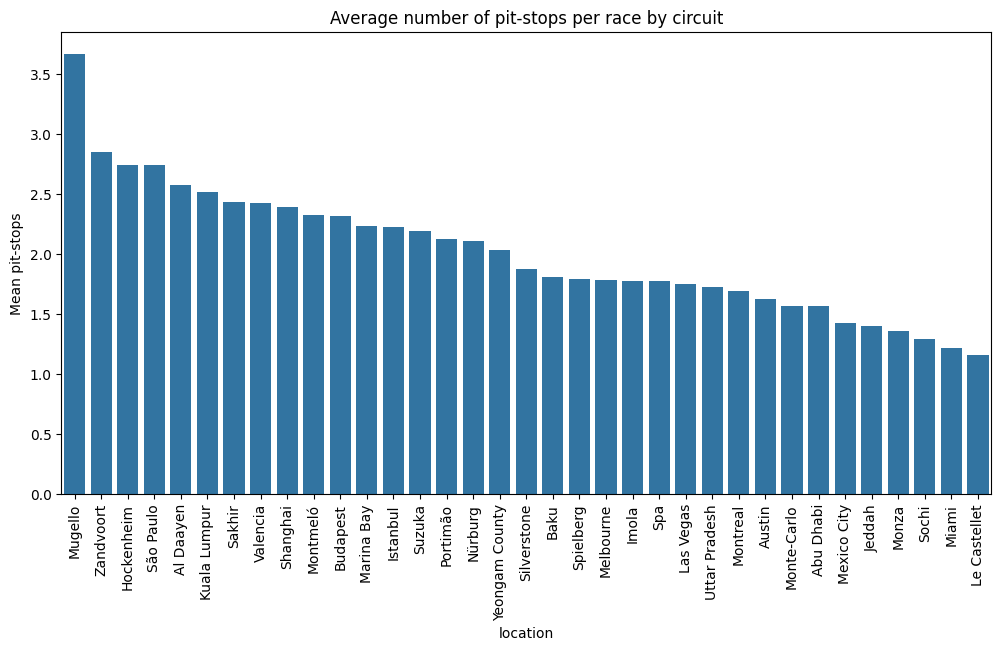

In [ ]:
mean_pits_by_track = (
    df_pits
    .groupby("location", as_index=False)
    .agg(mean_pits=("n_pits", "mean"))
    .sort_values("mean_pits", ascending=False)
)


plt.figure(figsize=(12,6))
sns.barplot(
    data=mean_pits_by_track,
    x="location",
    y="mean_pits",
)
plt.xticks(rotation=90)
plt.title("Average number of pit-stops per race by circuit")
plt.ylabel("Mean pit-stops")
plt.show()

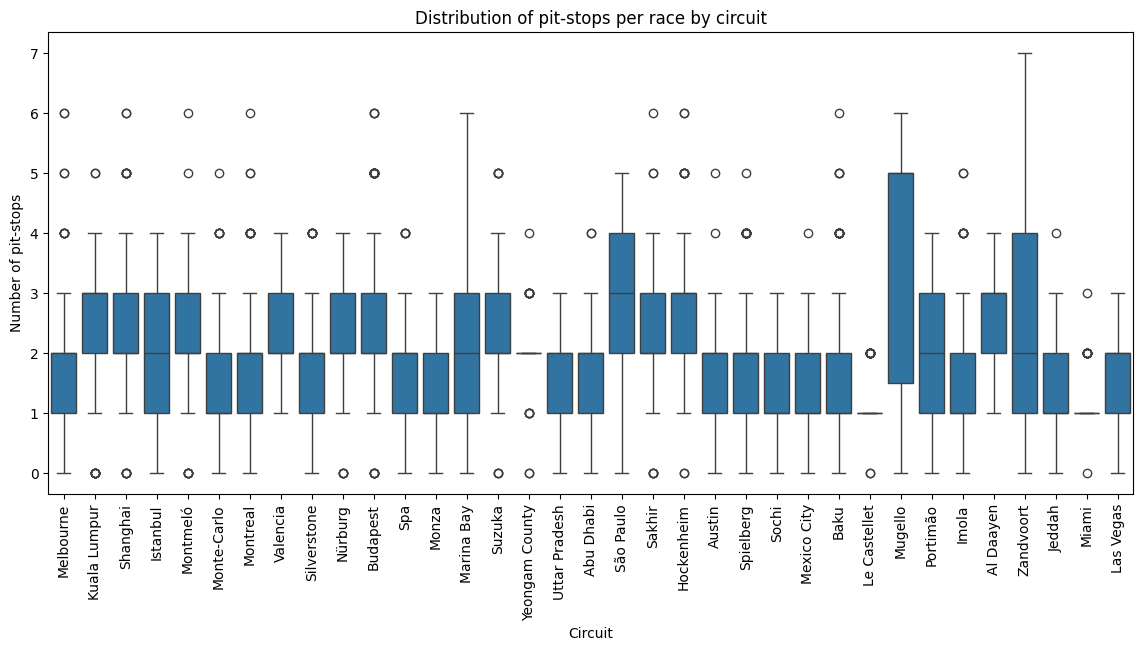

In [ ]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df_pits, x="location", y="n_pits")
plt.xticks(rotation=90)
plt.title("Distribution of pit-stops per race by circuit")
plt.ylabel("Number of pit-stops")
plt.xlabel("Circuit")
plt.show()

### 2) Time of pit-stops

In [ ]:
def pit_time_to_seconds(x):
    if pd.isna(x):
        return np.nan

    x = str(x)

    # формат mm:ss.xxx или m:ss.xxx
    if ":" in x:
        minutes, seconds = x.split(":")
        return int(minutes) * 60 + float(seconds)

    # формат просто seconds.xxx
    return float(x)

df["time_pit_sec"] = df["time_pit"].apply(pit_time_to_seconds)

df_pit_events = df[df["time_pit_sec"].notna()].copy()

df_clean_pits = df_pit_events[
    (df_pit_events["time_pit_sec"] >= 10) &
    (df_pit_events["time_pit_sec"] <= 40)
]

pit_time_by_year = (
    df_clean_pits
    .groupby("year", as_index=False)
    .agg(
        mean_pit_time=("time_pit_sec", "mean"),
        median_pit_time=("time_pit_sec", "median"),
        n_pits=("time_pit_sec", "count")
    )
)


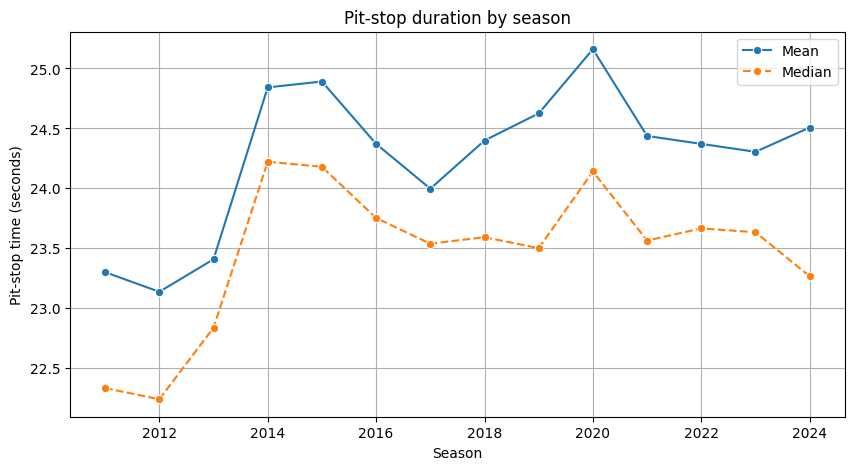

In [ ]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=pit_time_by_year,
    x="year",
    y="mean_pit_time",
    marker="o",
    label="Mean"
)

sns.lineplot(
    data=pit_time_by_year,
    x="year",
    y="median_pit_time",
    marker="o",
    linestyle="--",
    label="Median"
)

plt.title("Pit-stop duration by season")
plt.ylabel("Pit-stop time (seconds)")
plt.xlabel("Season")
plt.grid(True)
plt.legend()
plt.show()

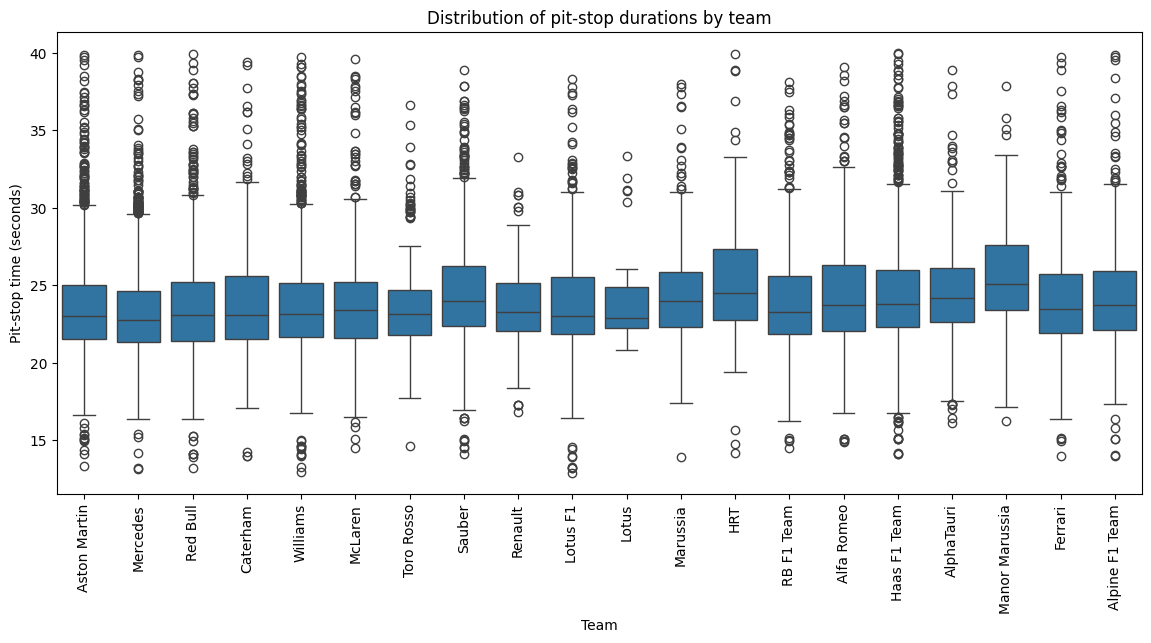

In [ ]:
pit_time_by_team = (
    df_pit_events
    .groupby("constructor", as_index=False)
    .agg(
        mean_pit_time=("time_pit_sec", "mean"),
        median_pit_time=("time_pit_sec", "median"),
        std_pit_time=("time_pit_sec", "std"),
        n_pits=("time_pit_sec", "count")
    )
    .sort_values("median_pit_time")
)

plt.figure(figsize=(14,6))
sns.boxplot(
    data=df_clean_pits,
    x="constructor",
    y="time_pit_sec"
)
plt.xticks(rotation=90)
plt.title("Distribution of pit-stop durations by team")
plt.ylabel("Pit-stop time (seconds)")
plt.xlabel("Team")
plt.show()



In [ ]:
pit_time_by_team = (
    df_clean_pits
    .groupby("constructor", as_index=False)
    .agg(
        mean_pit_time=("time_pit_sec", "mean"),
        n_pits=("time_pit_sec", "count")
    )
    .sort_values("mean_pit_time")
)

top3_teams = pit_time_by_team.head(3)
top3_teams

,constructor,mean_pit_time,n_pits
13,Mercedes,23.547409,1076
18,Toro Rosso,23.705354,237
3,Aston Martin,23.770021,1161


### 3) Position Change on Pit

In [ ]:
df = df.sort_values(["raceId", "driverId", "lap"])

df["position_prev"] = (df.groupby(["raceId", "driverId"])["position"].shift(1))
df["position_next"] = (df.groupby(["raceId", "driverId"])["position"].shift(-1))

df_pits_pos = df[df["time_pit_sec"].notna()].copy()
df_pits_pos["position_change_on_pit"] = (df_pits_pos["position_prev"] - df_pits_pos["position_next"])

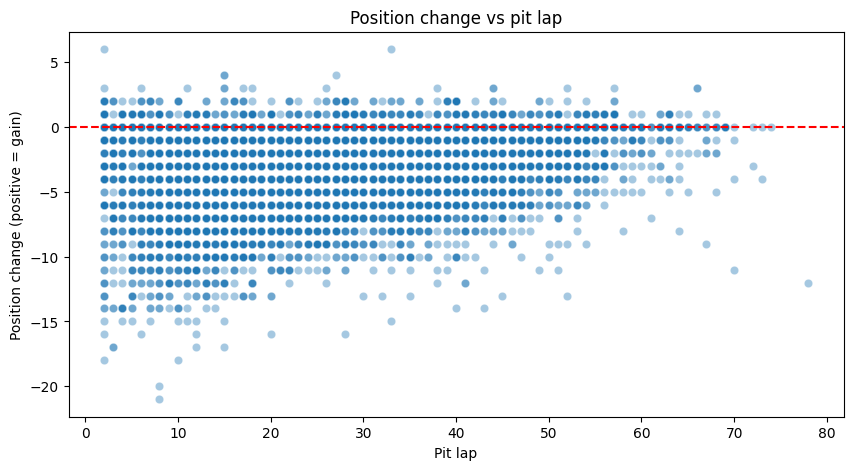

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    data=df_pits_pos,
    x="lap",
    y="position_change_on_pit",
    alpha=0.4
)
plt.axhline(0, color="red", linestyle="--")
plt.title("Position change vs pit lap")
plt.xlabel("Pit lap")
plt.ylabel("Position change (positive = gain)")
plt.show()

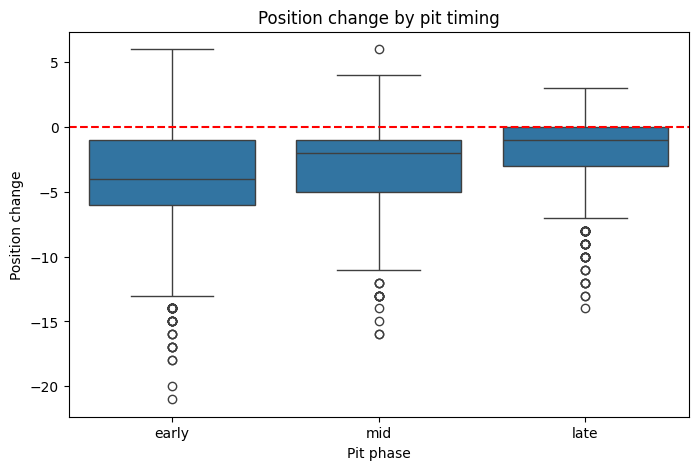

In [ ]:
max_lap = df.groupby("raceId")["lap"].transform("max")

df_pits_pos["pit_phase"] = pd.cut(
    df_pits_pos["lap"] / max_lap,
    bins=[0, 0.33, 0.66, 1.0],
    labels=["early", "mid", "late"]
)

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_pits_pos,
    x="pit_phase",
    y="position_change_on_pit"
)
plt.axhline(0, color="red", linestyle="--")
plt.title("Position change by pit timing")
plt.xlabel("Pit phase")
plt.ylabel("Position change")
plt.show()

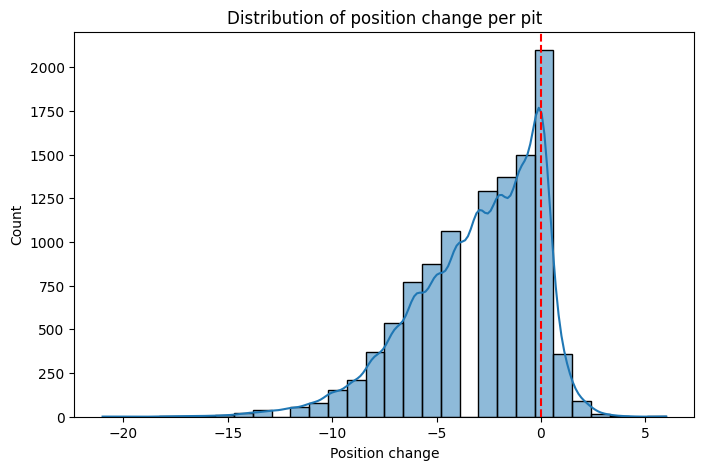

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(
    df_pits_pos["position_change_on_pit"],
    bins=30,
    kde=True
)
plt.axvline(0, color="red", linestyle="--")
plt.title("Distribution of position change per pit")
plt.xlabel("Position change")
plt.show()

### 4) Overtaking window

In [ ]:
def lap_time_to_sec(x):
    if pd.isna(x):
        return np.nan

    x = str(x)
    parts = x.split(":")

    try:
        if len(parts) == 3:
            # h:mm:ss.xxx
            h, m, s = parts
            return int(h) * 3600 + int(m) * 60 + float(s)

        elif len(parts) == 2:
            # m:ss.xxx
            m, s = parts
            return int(m) * 60 + float(s)

        elif len(parts) == 1:
            # ss.xxx
            return float(parts[0])

    except ValueError:
        return np.nan

df["lap_time_sec"] = df["time_lap"].apply(lap_time_to_sec)

df = df.sort_values(["raceId", "driverId", "lap"])

df["position_prev"] = (
    df.groupby(["raceId", "driverId"])["position"].shift(1)
)

df["position_next"] = (
    df.groupby(["raceId", "driverId"])["position"].shift(-1)
)

df["lap_time_before"] = (
    df.groupby(["raceId", "driverId"])["lap_time_sec"]
      .rolling(3).mean().shift(1)
      .reset_index(level=[0,1], drop=True)
)

df["lap_time_after"] = (
    df.groupby(["raceId", "driverId"])["lap_time_sec"]
      .rolling(3).mean().shift(-3)
      .reset_index(level=[0,1], drop=True)
)

df_pits_pos = df[df["time_pit_sec"].notna()].copy()
df_pits_pos["position_change_on_pit"] = (df_pits_pos["position_prev"] - df_pits_pos["position_next"])
df_pits_pos["pace_delta"] = (df_pits_pos["lap_time_before"] - df_pits_pos["lap_time_after"])

df_pits_pos["pit_lap_bin"] = pd.cut(
    df_pits_pos["lap"],
    bins=10
)

df_pits_pos["lap_frac"] = (
    df_pits_pos["lap"] /
    df_pits_pos.groupby("raceId")["lap"].transform("max")
)

df_pits_pos["pit_lap_bin"] = pd.qcut(
    df_pits_pos["lap_frac"],
    q=10,
    labels=[f"{i*10}–{(i+1)*10}%" for i in range(10)]
)

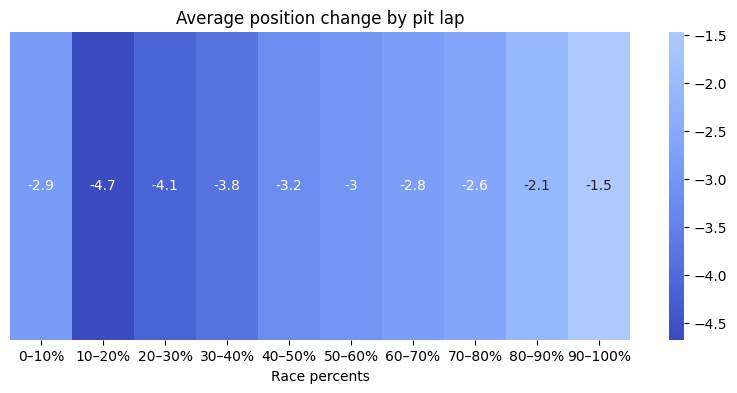

In [ ]:
heatmap_data = (
    df_pits_pos
    .groupby("pit_lap_bin", observed=True)["position_change_on_pit"]
    .mean()
)

plt.figure(figsize=(10,4))
sns.heatmap(
    heatmap_data.to_frame().T,
    cmap="coolwarm",
    center=0,
    annot=True
)
plt.title("Average position change by pit lap")
plt.xlabel("Race percents")
plt.yticks([])
plt.show()

### 5) Stints and tyre degradation

In [ ]:
df["is_pit"] = df["time_pit_sec"].notna()
df["stint"] = (
    df.groupby(["raceId", "driverId"])["is_pit"]
      .cumsum()
)

df["laps_since_pit"] = (
    df.groupby(["raceId", "driverId", "stint"])
      .cumcount()
)

stint_lengths = (
    df.groupby(["raceId", "driverId", "stint"])
      .agg(stint_length=("laps_since_pit", "max"))
      .reset_index()
)

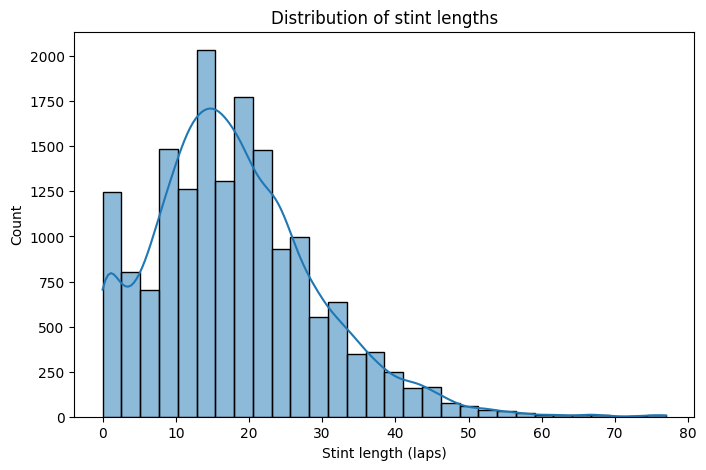

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(stint_lengths["stint_length"], bins=30, kde=True)
plt.title("Distribution of stint lengths")
plt.xlabel("Stint length (laps)")
plt.ylabel("Count")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

stint_pace = (df.dropna(subset=["lap_time_sec"])
      .groupby("laps_since_pit")["lap_time_sec"]
      .median()
      .reset_index()
)

df_stint = df[
    (df["laps_since_pit"] >= 2) &
    (df["laps_since_pit"] <= 20)
].dropna(subset=["lap_time_sec"])


df_stint["lap_time_norm"] = (
    df_stint["lap_time_sec"] -
    df_stint.groupby(["raceId", "driverId", "stint"])["lap_time_sec"].transform("min")
)


stint_deg = (
    df_stint
    .groupby("laps_since_pit")["lap_time_norm"]
    .median()
    .reset_index()
)

def stint_slope(x):
    if len(x) < 5:
        return np.nan
    X = x["laps_since_pit"].values.reshape(-1, 1)
    y = x["lap_time_sec"].values
    return LinearRegression().fit(X, y).coef_[0]

stint_slopes = (
    df_stint
    .groupby(["raceId", "driverId", "stint"])
    .apply(stint_slope)
    .reset_index(name="deg_s_per_lap")
)


stint_lengths = (
    df_stint
    .groupby(["raceId", "driverId", "stint"])
    .size()
    .reset_index(name="n_laps")
)

stint_slopes = stint_slopes.merge(
    stint_lengths,
    on=["raceId", "driverId", "stint"]
)

stint_slopes = stint_slopes.query("n_laps >= 8")

stint_slopes_clean = stint_slopes[
    stint_slopes["deg_s_per_lap"].between(-0.1, 0.3)
]

/tmp/ipython-input-59691/3725361192.py:40: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(stint_slope)


In [ ]:
clean_stints = stint_slopes_lvl2[
    ["raceId", "driverId", "stint"]
]

df_stint_clean = df.merge(
    clean_stints,
    on=["raceId", "driverId", "stint"],
    how="inner"
)

df_stint_clean = df_stint_clean[
    (df_stint_clean["laps_since_pit"] >= 2) &
    (df_stint_clean["laps_since_pit"] <= 20)
]

df_stint_clean["lap_time_delta"] = (
    df_stint_clean["lap_time_sec"] -
    df_stint_clean
        .groupby(["raceId", "driverId", "stint"])["lap_time_sec"]
        .transform("min")
)

stint_pace_clean = (df_stint_clean .groupby("laps_since_pit")["lap_time_delta"] .median().reset_index())

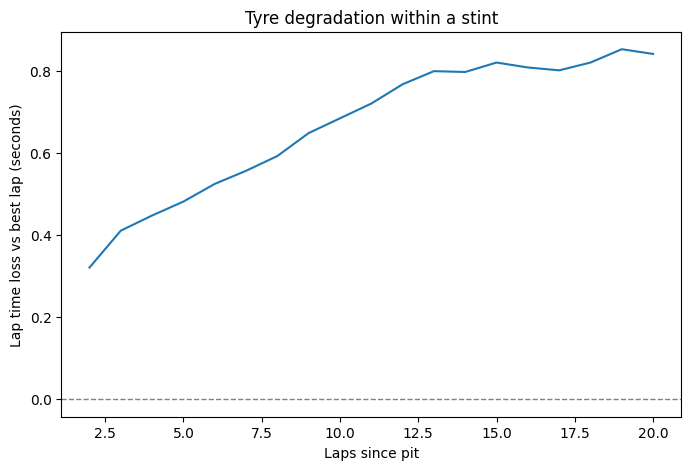

In [ ]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=stint_pace_clean,
    x="laps_since_pit",
    y="lap_time_delta"
)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)

plt.title("Tyre degradation within a stint")
plt.xlabel("Laps since pit")
plt.ylabel("Lap time loss vs best lap (seconds)")
plt.show()

### 6) Safety cars

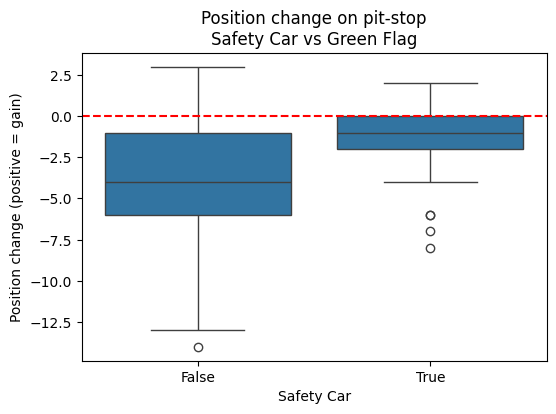

In [ ]:
def lap_time_to_sec_safe(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    parts = s.split(":")
    try:
        if len(parts) == 3:
            h, m, sec = parts
            return int(h) * 3600 + int(m) * 60 + float(sec)
        if len(parts) == 2:
            m, sec = parts
            return int(m) * 60 + float(sec)
        return float(parts[0])
    except:
        return np.nan

df_2024["lap_time_sec"] = df_2024["time_lap"].map(lap_time_to_sec_safe)

df_2024 = df_2024.sort_values(["raceId", "driverId", "lap"])

df_2024["position_prev"] = (
    df_2024.groupby(["raceId", "driverId"])["position"].shift(1)
)

df_2024["position_next"] = (
    df_2024.groupby(["raceId", "driverId"])["position"].shift(-1)
)

df_2024_pits = df_2024[df_2024["time_pit_sec"].notna()].copy()

df_2024_pits["position_change_on_pit"] = (
    df_2024_pits["position_prev"] - df_2024_pits["position_next"]
)

df_2024_pits[
    ["lap", "position_prev", "position_next", "position_change_on_pit"]
].head()

df_2024_stint = df_2024.dropna(subset=["lap_time_sec"]).copy()

df_2024_stint["lap_time_delta"] = (
    df_2024_stint["lap_time_sec"]
    - df_2024_stint
        .groupby(["raceId", "driverId", "Stint"])["lap_time_sec"]
        .transform("min")
)

plt.figure(figsize=(6,4))
sns.boxplot(
    data=df_2024_pits,
    x="safety_car",
    y="position_change_on_pit"
)
plt.axhline(0, linestyle="--", color="red")
plt.title("Position change on pit-stop\nSafety Car vs Green Flag")
plt.xlabel("Safety Car")
plt.ylabel("Position change")
plt.show()

### 7) Tyre compound

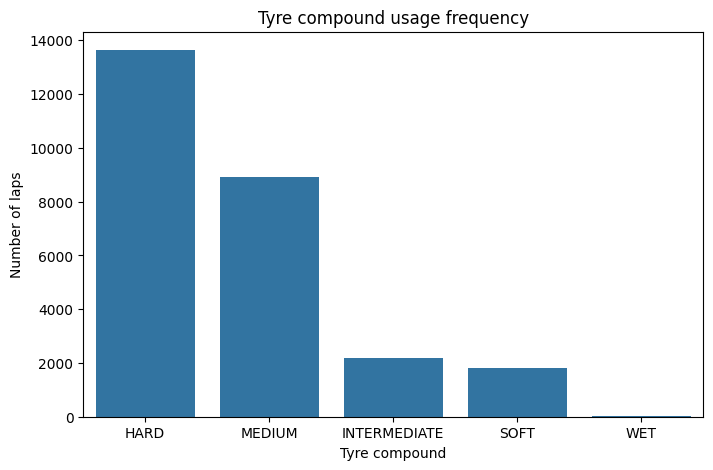

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_2024, x="tyre_compound", order=df_2024["tyre_compound"].value_counts().index)
plt.title("Tyre compound usage frequency")
plt.xlabel("Tyre compound")
plt.ylabel("Number of laps")
plt.show()

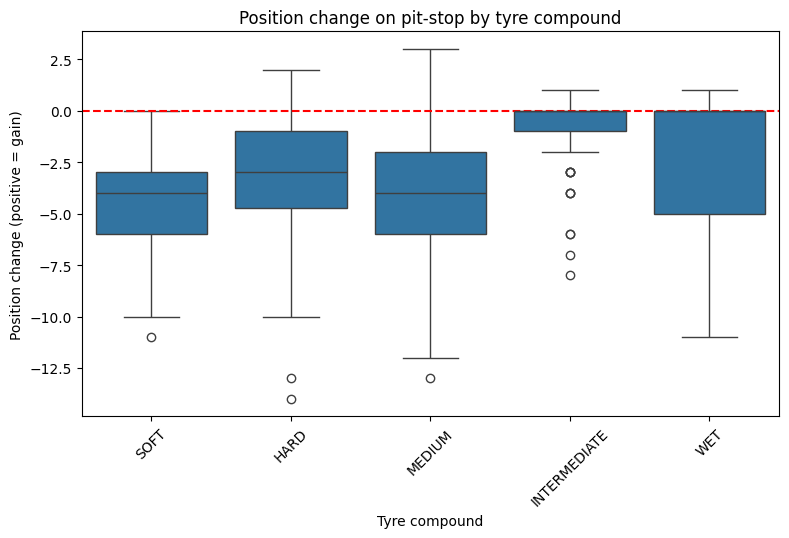

In [ ]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df_2024_pits, x="tyre_compound", y="position_change_on_pit")
plt.axhline(0, linestyle="--", color="red")
plt.title("Position change on pit-stop by tyre compound")
plt.xlabel("Tyre compound")
plt.ylabel("Position change (positive = gain)")
plt.xticks(rotation=45)
plt.show()

# Simulation Environment Development

- Track evolution model
- Tyre degradation model
- Safety car model
- Base peace model
- Pit-stop duration model

### Preprocessing

In [6]:
df['tyre_compound'] = df['tyre_compound'].astype(str)

# stint_time_delta
first_lap_in_stint = (
    df.groupby(['raceId', 'driver_code', 'stint'])['time_lap']
    .transform('first')
)
df['stint_time_delta'] = df['time_lap'] - first_lap_in_stint


CLEAN_MASK = (df['safety_car'] == 0) & (df['pit'] == 0) & (df['time_lap'] < 200)
df_clean = df[CLEAN_MASK].copy()

le_circuit     = LabelEncoder()
le_constructor = LabelEncoder()
le_driver      = LabelEncoder()
le_weather     = LabelEncoder()

df['circuit_id']     = le_circuit.fit_transform(df['circuitRef'])
df['constructor_id'] = le_constructor.fit_transform(df['constructor'])
df['driver_id']      = le_driver.fit_transform(df['driver_code'])
df['weather_id']     = le_weather.fit_transform(df['weather_type'])

df_clean['circuit_id']     = le_circuit.transform(df_clean['circuitRef'])
df_clean['constructor_id'] = le_constructor.transform(df_clean['constructor'])
df_clean['driver_id']      = le_driver.transform(df_clean['driver_code'])
df_clean['weather_id']     = le_weather.transform(df_clean['weather_type'])

race_laps = df_clean.groupby('raceId')['lap'].transform('max')
df_clean['lap_frac'] = df_clean['lap'] / race_laps

print(f"Clear laps (without SC / pit-stops): {len(df_clean):,}")
print(df_clean['stint_time_delta'].describe().round(3))

Clear laps (without SC / pit-stops): 293,039
count    293039.000
mean        -30.457
std         180.950
min       -3701.370
25%         -15.982
50%          -6.542
75%          -4.038
max          82.083
Name: stint_time_delta, dtype: float64


In [7]:
# Моделирование fuel load effect
FUEL_START_KG    = 110.0
FUEL_BURN_KG_LAP = 1.8
FUEL_TIME_EFFECT = 0.03   # секунды на кг

df_clean['fuel_laps_remaining'] = (
    df_clean.groupby(['raceId'])['lap']
    .transform(lambda x: x.max() - x)
)
df_clean['fuel_effect'] = (
    df_clean['fuel_laps_remaining'] * FUEL_BURN_KG_LAP * FUEL_TIME_EFFECT
)

### Track evolution

Track evolution (rubber-in effect) describes how track conditions
improve over the course of a race as rubber accumulates on the
racing surface. Modelled as a log function of lap fraction
(R²=0.984), fitted on laps with fresh tyres (tyre_life 4-8) where
any lap time improvement reflects track conditions rather than
tyre behaviour. The effect ranges from +3.3s at race start to
-1.7s at the end relative to mid-race pace.

In [12]:
# Существует ли резинизация?
# Только первые 5 кругов после пита — шины свежие, деградация минимальна, любой тренд здесь = резинизация
fresh = df_clean[df_clean['tyre_life'].between(4, 8)].copy()
fresh['lap_frac'] = fresh.groupby('raceId')['lap'].transform(lambda x: x / x.max())

fresh['base'] = fresh.groupby('raceId')['time_lap'].transform('median')
fresh['delta'] = fresh['time_lap'] - fresh['base']

avg = fresh.groupby(fresh['lap_frac'].round(1))['delta'].median()
print(avg)

lap_frac
0.0    3.35450
0.1    1.01100
0.2    0.75000
0.3    0.13900
0.4   -0.18250
0.5   -0.47250
0.6   -0.72725
0.7   -1.15475
0.8   -1.51750
0.9   -1.72025
1.0   -1.63975
Name: delta, dtype: float64


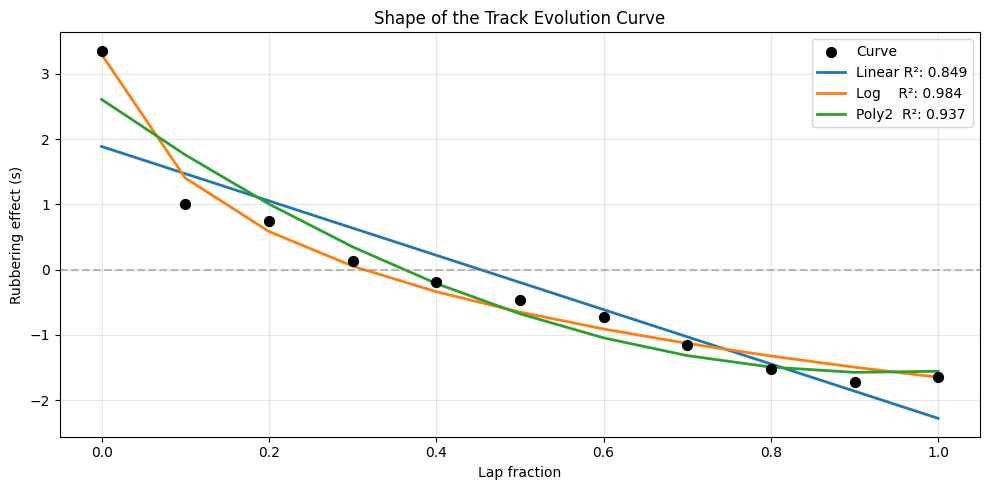

Linear R²: 0.849
Log    R²: 0.984
Poly2  R²: 0.937
Lineal coefficients: slope=-4.167, intercept=1.887
Log coefficients: a=-1.526, b=0.041, c=-1.590


In [13]:
# Подбираем функцию резинизации
from scipy.optimize import curve_fit

x = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
y = np.array([3.355, 1.011, 0.750, 0.139, -0.183, -0.473,
              -0.727, -1.155, -1.518, -1.720, -1.640])

# Пробуем три формы
# 1) Линейная
coeffs_lin = np.polyfit(x, y, 1)
y_lin = np.polyval(coeffs_lin, x)

# 2) Логарифмическая: a * log(x+b) + c
def log_func(x, a, b, c):
    return a * np.log(x + b) + c
popt_log, _ = curve_fit(log_func, x, y, p0=[-2, 0.1, 2], maxfev=5000)
y_log = log_func(x, *popt_log)

# 3) Полином 2й степени
coeffs_poly = np.polyfit(x, y, 2)
y_poly = np.polyval(coeffs_poly, x)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x, y, color='black', zorder=5, s=50, label='Curve')
ax.plot(x, y_lin,  label=f"Linear R²: {r2_score(y, y_lin):.3f}", linewidth=2)
ax.plot(x, y_log,  label=f"Log    R²: {r2_score(y, y_log):.3f}", linewidth=2)
ax.plot(x, y_poly, label=f"Poly2  R²: {r2_score(y, y_poly):.3f}", linewidth=2)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Lap fraction'); ax.set_ylabel('Rubbering effect (s)')
ax.set_title('Shape of the Track Evolution Curve')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
#plt.savefig('shape_of_track_evolution_curve.png', dpi=150, bbox_inches='tight')
plt.show();

# Метрики подгонки
from sklearn.metrics import r2_score
print(f"Linear R²: {r2_score(y, y_lin):.3f}")
print(f"Log    R²: {r2_score(y, y_log):.3f}")
print(f"Poly2  R²: {r2_score(y, y_poly):.3f}")

print(f"Lineal coefficients: slope={coeffs_lin[0]:.3f}, intercept={coeffs_lin[1]:.3f}")
print(f"Log coefficients: a={popt_log[0]:.3f}, b={popt_log[1]:.3f}, c={popt_log[2]:.3f}")

In [14]:
# Target degradation clean

# Функция резинизации
def rubbering_effect(lap_frac, a=-1.526, b=0.041, c=-1.590):
    return a * np.log(lap_frac + b) + c

# Считаем base_pace
base_pace = (
    df_clean[
        df_clean['tyre_life'].between(3, 6) &
        (df_clean['stint'] == 1)
    ]
    .groupby(['raceId', 'driver_code'])['time_lap']
    .median()
)
base_pace.name = 'base_pace'

df_clean = df_clean.join(base_pace, on=['raceId', 'driver_code'])
df_clean['rubbering'] = df_clean['lap_frac'].apply(rubbering_effect)

# Якорные круги (3-6 первого стинта)
anchor_laps = df_clean[
    df_clean['tyre_life'].between(3, 6) & (df_clean['stint'] == 1)
]
anchor_lap_frac = anchor_laps.groupby(['raceId', 'driver_code'])['lap_frac'].median()
anchor_lap_frac.name = 'anchor_lap_frac'
df_clean = df_clean.join(anchor_lap_frac, on=['raceId', 'driver_code'])

# Резинизация на момент якоря
df_clean['rubbering_anchor'] = df_clean['anchor_lap_frac'].apply(
    lambda x: rubbering_effect(x) if pd.notna(x) else 0.
)

# Скорректированная резинизация
df_clean['rubbering_corrected'] = df_clean['rubbering'] - df_clean['rubbering_anchor']

# Новый таргет
df_clean['target_degrad_clean'] = (
    df_clean['time_lap'] - df_clean['base_pace'] - df_clean['rubbering_corrected']
)

# Проверка
print("New target (SOFT, 2022-2024):")
check = df_clean[
    (df_clean['tyre_compound'] == 'SOFT') &
    (df_clean['year'] >= 2022) &
    (df_clean['tyre_life'].between(3, 35)) &
    (df_clean['base_pace'].notna())
].groupby('tyre_life')['target_degrad_clean'].median()
print(check.round(3).to_string())

New target (SOFT, 2022-2024):
tyre_life
3     -0.297
4     -0.140
5      0.165
6      0.363
7      0.600
8      0.739
9      0.909
10     0.989
11     1.046
12     1.131
13     1.224
14     1.286
15     1.250
16     1.376
17     1.441
18     1.329
19     1.368
20     1.351
21     1.501
22     1.548
23     1.557
24     1.642
25     1.531
26     1.345
27     1.685
28     1.556
29     1.310
30     1.322
31     1.744
32     1.619
33     1.694
34   -11.985
35   -12.017


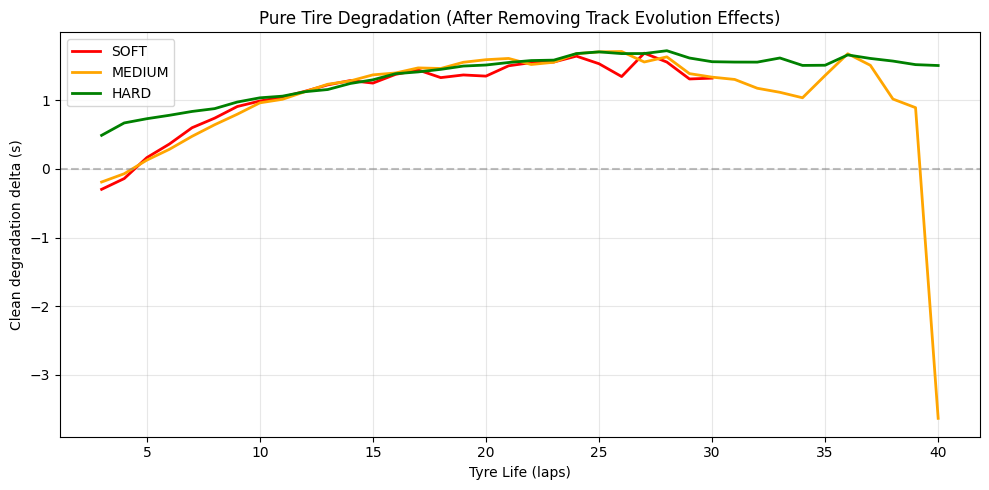

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

for comp, color in [('SOFT','red'), ('MEDIUM','orange'), ('HARD','green')]:
    check = df_clean[
        (df_clean['tyre_compound'] == comp) &
        (df_clean['year'] >= 2022) &
        (df_clean['tyre_life'].between(3, 40)) &
        (df_clean['base_pace'].notna())
    ].groupby('tyre_life')['target_degrad_clean'].median()

    # Убираем tyre_life где мало данных
    n = df_clean[
        (df_clean['tyre_compound'] == comp) &
        (df_clean['year'] >= 2022) &
        (df_clean['tyre_life'].between(3, 40))
    ].groupby('tyre_life').size()
    check = check[n[check.index] >= 20]

    ax.plot(check.index, check.values, label=comp, color=color, linewidth=2)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Tyre Life (laps)')
ax.set_ylabel('Clean degradation delta (s)')
ax.set_title('Pure Tire Degradation (After Removing Track Evolution Effects)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [16]:
'''
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Левый: до коррекции (старый таргет)
ax = axes[0]
for comp, color in [('SOFT','red'), ('MEDIUM','orange'), ('HARD','green')]:
    mask = (
        (df_clean['tyre_compound'] == comp) &
        (df_clean['year'] >= 2022) &
        (df_clean['tyre_life'].between(3, 40)) &
        (df_clean['base_pace'].notna())
    )
    # Старый таргет: time_lap - base_pace (без вычета резинизации)
    old_target = df_clean.loc[mask, 'time_lap'] - df_clean.loc[mask, 'base_pace']
    avg = old_target.groupby(df_clean.loc[mask, 'tyre_life']).median()
    n   = old_target.groupby(df_clean.loc[mask, 'tyre_life']).size()
    avg = avg[n[avg.index] >= 20]
    ax.plot(avg.index, avg.values, label=comp, color=color, linewidth=2)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Tyre Life (laps)')
ax.set_ylabel('Delta from base pace (s)')
ax.set_title('Before Track Evolution Correction\n(degradation + rubbering mixed)')
ax.legend(); ax.grid(alpha=0.3)
ax.set_ylim(-3, 4)
ax.set_xlim(3, 35)

# Правый: после коррекции (чистая деградация)
ax = axes[1]
for comp, color in [('SOFT','red'), ('MEDIUM','orange'), ('HARD','green')]:
    mask = (
        (df_clean['tyre_compound'] == comp) &
        (df_clean['year'] >= 2022) &
        (df_clean['tyre_life'].between(3, 40)) &
        (df_clean['target_degrad_clean'].notna()) &
        (df_clean['base_pace'].notna())
    )
    avg = df_clean.loc[mask].groupby('tyre_life')['target_degrad_clean'].median()
    n   = df_clean.loc[mask].groupby('tyre_life').size()
    avg = avg[n[avg.index] >= 20]
    ax.plot(avg.index, avg.values, label=comp, color=color, linewidth=2)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Tyre Life (laps)')
ax.set_ylabel('Clean degradation delta (s)')
ax.set_title('After Track Evolution Correction\n(pure tyre degradation)')
ax.legend(); ax.grid(alpha=0.3)
ax.set_ylim(-3, 4)
ax.set_xlim(3, 35)

plt.suptitle('Effect of Track Evolution Correction on Tyre Degradation Signal\n(Silverstone 2022–2024)',
             fontsize=13)
plt.tight_layout()
plt.savefig('track_evolution_correction.png', dpi=150, bbox_inches='tight')
plt.show()
'''

"\nfig, axes = plt.subplots(1, 2, figsize=(14, 5))\n\n# Левый: до коррекции (старый таргет)\nax = axes[0]\nfor comp, color in [('SOFT','red'), ('MEDIUM','orange'), ('HARD','green')]:\n    mask = (\n        (df_clean['tyre_compound'] == comp) &\n        (df_clean['year'] >= 2022) &\n        (df_clean['tyre_life'].between(3, 40)) &\n        (df_clean['base_pace'].notna())\n    )\n    # Старый таргет: time_lap - base_pace (без вычета резинизации)\n    old_target = df_clean.loc[mask, 'time_lap'] - df_clean.loc[mask, 'base_pace']\n    avg = old_target.groupby(df_clean.loc[mask, 'tyre_life']).median()\n    n   = old_target.groupby(df_clean.loc[mask, 'tyre_life']).size()\n    avg = avg[n[avg.index] >= 20]\n    ax.plot(avg.index, avg.values, label=comp, color=color, linewidth=2)\n\nax.axhline(0, color='gray', linestyle='--', alpha=0.5)\nax.set_xlabel('Tyre Life (laps)')\nax.set_ylabel('Delta from base pace (s)')\nax.set_title('Before Track Evolution Correction\n(degradation + rubbering mixed)'

### Tyre degradation model

Pure tyre degradation is isolated by subtracting the track
evolution effect from each lap time delta. Target:
time_lap − base_pace − rubbering_corrected, where base_pace
is the median of laps 3-6 of the first stint per driver per race.
A separate XGBoost model is trained per compound (SOFT/MEDIUM/HARD/
INTERMEDIATE) on 2021-2024 data where compound is known, also a
general model covering 2011-2020. MAE ≈ 0.5s, R² ≈ 0.5.

Total training rows: 217,634
[Tyre — ALL]          MAE=0.672s  R2=0.447  n=174,107
[Tyre — SOFT        ] MAE=0.502s  R2=0.500  n=5,735
[Tyre — MEDIUM      ] MAE=0.512s  R2=0.586  n=17,108
[Tyre — HARD        ] MAE=0.531s  R2=0.522  n=24,556
[Tyre — INTERMEDIATE] MAE=0.715s  R2=0.505  n=2,106
[Tyre — WET         ] skipping (insufficient data: 99)


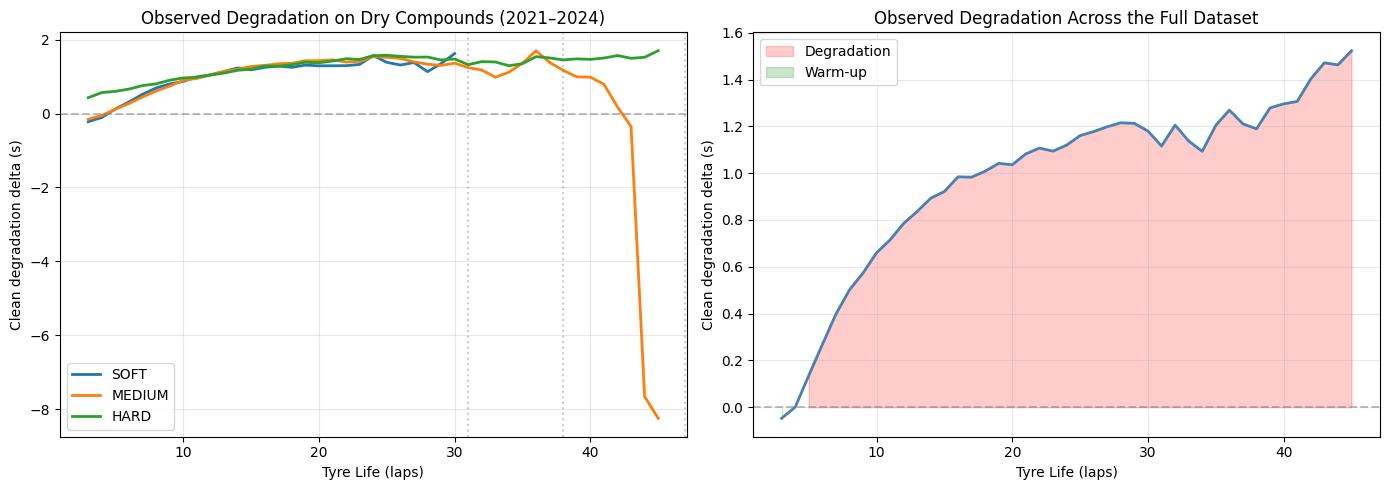

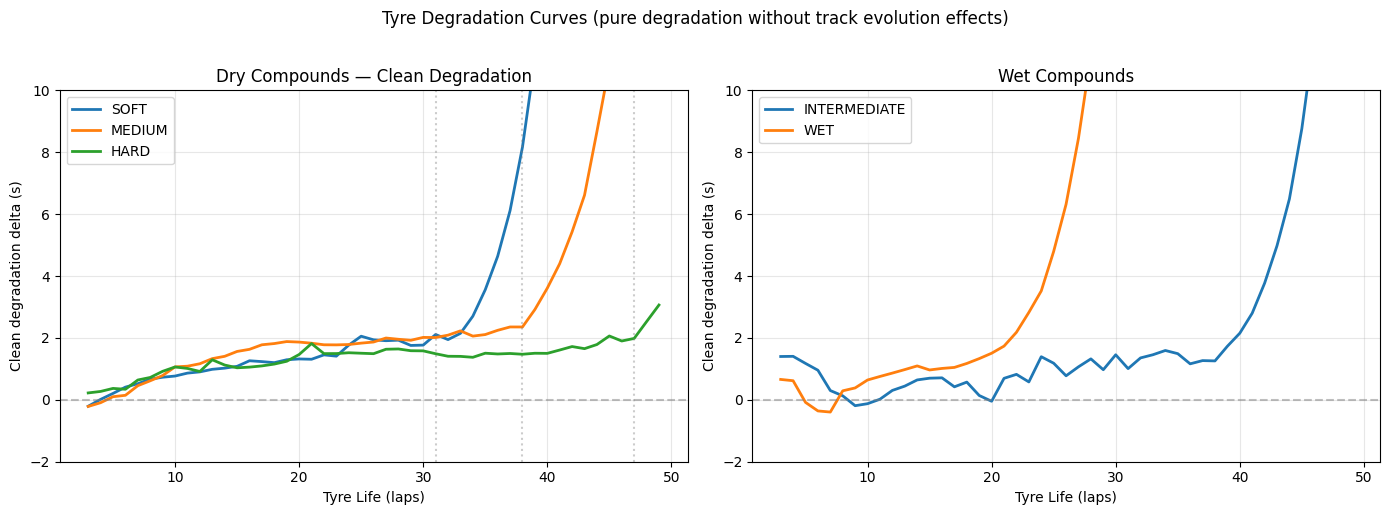

In [17]:
class TyreDegradationModel:
    # Таргет: чистая деградация шин после вычета резинизации трассы
    # target_degrad_clean = (time_lap - base_pace) - rubbering_corrected
    # Резинизация: log-функция от lap_frac, скорректированная на якорные круги
    # fuel_effect учитывает облегчение машины по ходу гонки

    COMPOUNDS_ORDER     = {'SOFT': 0, 'MEDIUM': 1, 'HARD': 2, 'INTERMEDIATE': 3, 'WET': 4}
    COMPOUNDS_LIST      = ['SOFT', 'MEDIUM', 'HARD', 'INTERMEDIATE', 'WET']
    COMPOUND_BASE_DELTA = {'SOFT': -0.4, 'MEDIUM': 0., 'HARD': 0.5,
                           'INTERMEDIATE': 1.2, 'WET': 2.5}

    MAX_TYRE_LIFE = {'SOFT': 31, 'MEDIUM': 38, 'HARD': 47,
                     'INTERMEDIATE': 38, 'WET': 20}

    FUEL_BURN_KG_LAP = 1.8
    FUEL_TIME_EFFECT = 0.03

    # Параметры резинизации (из подгонки log-функции)
    RUBBERING_A = -1.526
    RUBBERING_B =  0.041
    RUBBERING_C = -1.590

    XGB_PARAMS = dict(
        n_estimators=500, max_depth=5, learning_rate=0.04,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=20, random_state=42
    )

    def __init__(self):
        self.models         = {}
        self.fitted         = False
        self.base_pace_map_ = None

    @staticmethod
    def rubbering_effect(lap_frac, a=-1.526, b=0.041, c=-1.590):
        return a * np.log(lap_frac + b) + c

    @staticmethod
    def compute_base_pace(df_clean):
        base = (
            df_clean[
                df_clean['tyre_life'].between(3, 6) &
                (df_clean['stint'] == 1)
            ]
            .groupby(['raceId', 'driver_code'])['time_lap']
            .median()
        )
        base.name = 'base_pace'
        return base

    @staticmethod
    def recover_tyre_life(df):
        tyre_life_calc = (
            df.groupby(['raceId', 'driver_code', 'stint']).cumcount() + 1
        )
        result = df['tyre_life'].copy()
        missing = result.isna()
        result[missing] = tyre_life_calc[missing]
        return result

    @staticmethod
    def add_poly_features(d):
        tl = d['tyre_life_model']
        d['tyre_life_sq']    = tl ** 2
        d['tyre_life_cube']  = tl ** 3
        d['tyre_life_sqrt']  = tl ** 0.5
        d['tyre_life_log']   = np.log1p(tl)
        d['compound_x_life'] = d['compound_num'].clip(0) * tl
        return d

    def _base_features(self):
        return [
            'tyre_life_model', 'tyre_life_sq', 'tyre_life_cube',
            'tyre_life_sqrt', 'tyre_life_log', 'compound_x_life',
            'compound_num', 'lap_frac',
            'weather_id', 'circuit_id',
            'temperature', 'humidity', 'wind_speed', 'precipitation',
            'circuit_degrad_tendency',
            'fuel_effect',
        ]

    def fit(self, df_clean):
        d = df_clean.copy()

        # 1) Восстанавливаем tyre_life везде
        d['tyre_life_model'] = self.recover_tyre_life(d)

        # 2) Топливный эффект
        total_laps       = d.groupby('raceId')['lap'].transform('max')
        d['fuel_effect'] = (total_laps - d['lap']) * self.FUEL_BURN_KG_LAP * self.FUEL_TIME_EFFECT

        # 3) Используем target_degrad_clean если есть, иначе пересчитываем
        if 'target_degrad_clean' not in d.columns:
            print("Пересчитываем target_degrad_clean...")
            base_pace = self.compute_base_pace(d)
            d = d.join(base_pace, on=['raceId', 'driver_code'])

            # Резинизация
            d['rubbering'] = d['lap_frac'].apply(self.rubbering_effect)

            # Якорная резинизация
            anchor_laps = d[d['tyre_life_model'].between(3, 6) & (d['stint'] == 1)]
            anchor_lap_frac = anchor_laps.groupby(
                ['raceId', 'driver_code'])['lap_frac'].median()
            anchor_lap_frac.name = 'anchor_lap_frac'
            d = d.join(anchor_lap_frac, on=['raceId', 'driver_code'])
            d['rubbering_anchor']    = d['anchor_lap_frac'].apply(
                lambda x: self.rubbering_effect(x) if pd.notna(x) else 0.)
            d['rubbering_corrected'] = d['rubbering'] - d['rubbering_anchor']
            d['target_degrad_clean'] = (
                d['time_lap'] - d['base_pace'] - d['rubbering_corrected']
            )
        else:
            if 'base_pace' not in d.columns:
                base_pace = self.compute_base_pace(d)
                d = d.join(base_pace, on=['raceId', 'driver_code'])

        # 4) compound_num
        d['compound_num'] = d['tyre_compound'].map(self.COMPOUNDS_ORDER).fillna(-1)

        # 5) Трековая тенденция к деградации (по новому таргету)
        track_tend = (
            d[d['tyre_life_model'] > 5]
            .groupby('circuitRef')['target_degrad_clean']
            .median()
        )
        self.track_tendency_ = track_tend
        d['circuit_degrad_tendency'] = d['circuitRef'].map(track_tend).fillna(0)

        # 6) Полиномиальные признаки
        d = self.add_poly_features(d)

        # 7) Фильтрация:
        #    - убираем nulls в таргете и base_pace
        #    - убираем аут-лап (tyre_life <= 2) — там аномальные значения
        #    - убираем выбросы
        d = d[d['target_degrad_clean'].notna()]
        d = d[d['base_pace'].notna()]
        d = d[d['tyre_life_model'] > 2]
        d = d[d['target_degrad_clean'].between(-3, 8)]
        d = d[d['tyre_life_model'].notna()]

        feats = self._base_features()
        print(f"Total training rows: {len(d):,}")

        # 8) Общая модель
        X_all = d[feats].fillna(0)
        y_all = d['target_degrad_clean']
        Xtr, Xv, ytr, yv = train_test_split(X_all, y_all, test_size=0.2, random_state=42)
        model_all = XGBRegressor(**self.XGB_PARAMS)
        model_all.fit(Xtr, ytr, eval_set=[(Xv, yv)], verbose=False)
        pred = model_all.predict(Xv)
        self.models['all'] = model_all
        print(f"[Tyre — ALL]          MAE={mean_absolute_error(yv, pred):.3f}s  "
              f"R2={r2_score(yv, pred):.3f}  n={len(Xtr):,}")

        # 9) Отдельные модели на каждый compound
        for comp in self.COMPOUNDS_LIST:
            dc = d[d['tyre_compound'] == comp]
            if len(dc) < 500:
                print(f"[Tyre — {comp:12s}] skipping (insufficient data: {len(dc)})")
                continue
            Xc = dc[feats].fillna(0)
            yc = dc['target_degrad_clean']
            Xtr, Xv, ytr, yv = train_test_split(Xc, yc, test_size=0.2, random_state=42)
            m = XGBRegressor(**self.XGB_PARAMS)
            m.fit(Xtr, ytr, eval_set=[(Xv, yv)], verbose=False)
            pred_c = m.predict(Xv)
            self.models[comp] = m
            print(f"[Tyre — {comp:12s}] MAE={mean_absolute_error(yv, pred_c):.3f}s  "
                  f"R2={r2_score(yv, pred_c):.3f}  n={len(Xtr):,}")

        self.fitted = True


    def _make_x(self, tyre_life, compound, lap_frac,
                weather_id, circuit_id, temperature,
                humidity, wind_speed, precipitation,
                fuel_effect=0.):
        compound_num = self.COMPOUNDS_ORDER.get(compound, -1)
        tl = float(tyre_life)
        circuit_tend = float(
            self.track_tendency_.get(
                self.track_tendency_.index[circuit_id]
                if circuit_id < len(self.track_tendency_) else self.track_tendency_.index[0],
                0.
            )
        ) if hasattr(self, 'track_tendency_') else 0.
        return np.array([[
            tl, tl**2, tl**3, tl**0.5, np.log1p(tl),
            max(compound_num, 0) * tl,
            compound_num, lap_frac,
            weather_id, circuit_id,
            temperature, humidity, wind_speed, precipitation,
            circuit_tend,
            fuel_effect,
        ]])

    def predict_delta(self, tyre_life, compound, lap_frac,
                      weather_id=0, circuit_id=0, temperature=25.,
                      humidity=50., wind_speed=10., precipitation=0.,
                      fuel_effect=0., use_main=True):
        if not self.fitted:
            base = self.COMPOUND_BASE_DELTA.get(compound, 0.)
            return base + 0.07 * tyre_life

        X = self._make_x(tyre_life, compound, lap_frac,
                         weather_id, circuit_id, temperature,
                         humidity, wind_speed, precipitation,
                         fuel_effect)

        if compound in self.models:
            pred = float(self.models[compound].predict(X)[0])
        else:
            pred = float(self.models['all'].predict(X)[0])

        cap = self.MAX_TYRE_LIFE.get(compound, 38)
        if tyre_life > cap:
            overshoot = tyre_life - cap
            pred += np.exp(overshoot * 0.3) - 1

        return pred


    def plot_degradation_curves(self, circuit_id=0, weather_id=0,
                                temperature=25., humidity=50.,
                                wind_speed=10., precipitation=0.,
                                total_laps=50):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        tyre_lives = np.arange(3, 50)

        for comp in ['SOFT', 'MEDIUM', 'HARD']:
            deltas = [
                self.predict_delta(
                    tl, comp, tl/total_laps,
                    weather_id, circuit_id, temperature,
                    humidity, wind_speed, precipitation,
                    fuel_effect=(total_laps - tl) * self.FUEL_BURN_KG_LAP * self.FUEL_TIME_EFFECT
                )
                for tl in tyre_lives
            ]
            cap = self.MAX_TYRE_LIFE[comp]
            axes[0].plot(tyre_lives, deltas, label=comp, linewidth=2)
            axes[0].axvline(cap, color='gray', linestyle=':', alpha=0.4)
        axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
        axes[0].set_xlabel('Tyre Life (laps)')
        axes[0].set_ylabel('Clean degradation delta (s)')
        axes[0].set_title('Dry Compounds — Clean Degradation')
        axes[0].legend(); axes[0].grid(alpha=0.3)
        axes[0].set_ylim(-2, 10)

        for comp in ['INTERMEDIATE', 'WET']:
            deltas = [
                self.predict_delta(
                    tl, comp, tl/total_laps, 1,
                    circuit_id, temperature, humidity, wind_speed, precipitation,
                    fuel_effect=(total_laps - tl) * self.FUEL_BURN_KG_LAP * self.FUEL_TIME_EFFECT
                )
                for tl in tyre_lives
            ]
            axes[1].plot(tyre_lives, deltas, label=comp, linewidth=2)
        axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
        axes[1].set_xlabel('Tyre Life (laps)')
        axes[1].set_ylabel('Clean degradation delta (s)')
        axes[1].set_title('Wet Compounds')
        axes[1].legend(); axes[1].grid(alpha=0.3)
        axes[1].set_ylim(-2, 10)

        plt.suptitle('Tyre Degradation Curves (pure degradation without track evolution effects)',
                     fontsize=12, y=1.02)
        plt.tight_layout(); plt.show()

    def plot_real_curves(self, df_clean):
        d = df_clean.copy()
        d['tyre_life_model'] = self.recover_tyre_life(d)

        if 'target_degrad_clean' not in d.columns:
            print("target_degrad_clean не найден в df_clean")
            return

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        for comp in ['SOFT', 'MEDIUM', 'HARD']:
            mask = (
                (d['tyre_compound'] == comp) &
                (d['tyre_life_model'].between(3, 45)) &
                (d['target_degrad_clean'].notna())
            )
            n   = d[mask].groupby('tyre_life_model').size()
            avg = d[mask].groupby('tyre_life_model')['target_degrad_clean'].median()
            avg = avg[n[avg.index] >= 20]
            axes[0].plot(avg.index, avg.values, label=comp, linewidth=2)
            axes[0].axvline(self.MAX_TYRE_LIFE[comp],
                            color='gray', linestyle=':', alpha=0.4)
        axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
        axes[0].set_xlabel('Tyre Life (laps)')
        axes[0].set_ylabel('Clean degradation delta (s)')
        axes[0].set_title('Observed Degradation on Dry Compounds (2021–2024)')
        axes[0].legend(); axes[0].grid(alpha=0.3)

        mask_all = (
            (d['tyre_life_model'].between(3, 45)) &
            (d['target_degrad_clean'].notna())
        )
        n_all   = d[mask_all].groupby('tyre_life_model').size()
        avg_all = d[mask_all].groupby('tyre_life_model')['target_degrad_clean'].median()
        avg_all = avg_all[n_all[avg_all.index] >= 50]
        axes[1].plot(avg_all.index, avg_all.values, color='steelblue', linewidth=2)
        axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
        axes[1].fill_between(avg_all.index, avg_all.values, 0,
                             where=(avg_all.values > 0), alpha=0.2,
                             color='red', label='Degradation')
        axes[1].fill_between(avg_all.index, avg_all.values, 0,
                             where=(avg_all.values < 0), alpha=0.2,
                             color='green', label='Warm-up')
        axes[1].set_xlabel('Tyre Life (laps)')
        axes[1].set_ylabel('Clean degradation delta (s)')
        axes[1].set_title('Observed Degradation Across the Full Dataset')
        axes[1].legend(); axes[1].grid(alpha=0.3)

        plt.tight_layout(); plt.show()


tyre_model = TyreDegradationModel()
tyre_model.fit(df_clean)

tyre_model.plot_real_curves(df_clean)
tyre_model.plot_degradation_curves()

### Safety car model
1) Will there be a Safety Car during the race / on this lap?
2) Duration of safety car

In [18]:
from sklearn.model_selection import GroupShuffleSplit

class SafetyCarModel:
    # Двухуровневая модель:
    # 1. Race-level XGB: P(SC хотя бы раз в гонке)
    # 2. Lap-level XGB:  P(SC начинается на этом круге)

    def __init__(self):
        self.race_model = XGBClassifier(n_estimators=200, max_depth=4,
                                        eval_metric='logloss', random_state=42)
        self.lap_model  = XGBClassifier(n_estimators=300, max_depth=5,
                                        eval_metric='logloss',
                                        scale_pos_weight=50,
                                        random_state=42)
        self.SC_DURATION_MEAN  = 5.0
        self.SC_DURATION_STD   = 2.0
        self.sc_durations_     = []
        self.circuit_sc_rate_  = {}   # circuitRef -> historical SC rate
        self.global_sc_rate_   = 0.05
        self.fitted = False

    @staticmethod
    def _compute_sc_durations(df):
        sc_durations = []
        for race_id, group in df.groupby('raceId'):
            laps = group.sort_values('lap').drop_duplicates('lap')
            in_sc, duration = False, 0
            for _, row in laps.iterrows():
                if row['safety_car'] == 1:
                    in_sc = True
                    duration += 1
                elif in_sc:
                    sc_durations.append(duration)
                    in_sc = False
                    duration = 0
            if in_sc:
                sc_durations.append(duration)
        return sc_durations

    @staticmethod
    def _make_lap_df(df):
        dl = df.copy().sort_values(['raceId', 'driver_code', 'lap'])
        dl['sc_prev'] = (
            dl.groupby(['raceId', 'driver_code'])['safety_car']
            .shift(1).fillna(0)
        )
        dl['sc_start'] = (
            (dl['safety_car'] == 1) & (dl['sc_prev'] == 0)
        ).astype(int)
        dl['lap_frac'] = (
            dl.groupby('raceId')['lap'].transform(lambda x: x / x.max())
        )
        return dl

    LAP_FEATURES = ['lap_frac', 'weather_id', 'circuit_id',
                    'temperature', 'precipitation', 'humidity',
                    'wind_speed', 'year', 'circuit_sc_rate']

    def _add_circuit_sc_rate(self, dl, train_race_ids=None):
        # SC rate по треку
        if train_race_ids is not None:
            train_data = dl[dl['raceId'].isin(train_race_ids)]
        else:
            train_data = dl
        rate = (
            train_data
            .drop_duplicates(['raceId', 'lap'])
            .groupby('circuitRef')['safety_car']
            .mean()
        )
        self.circuit_sc_rate_ = rate.to_dict()
        self.global_sc_rate_  = float(rate.mean())
        dl['circuit_sc_rate'] = (
            dl['circuitRef']
            .map(self.circuit_sc_rate_)
            .fillna(self.global_sc_rate_)
        )
        return dl

    def fit(self, df):
        # Race-level
        rf = df.groupby('raceId').agg(
            sc_deployed  = ('safety_car',    'max'),
            weather_id   = ('weather_id',   'first'),
            temperature  = ('temperature',  'first'),
            precipitation= ('precipitation','first'),
            humidity     = ('humidity',     'first'),
            wind_speed   = ('wind_speed',   'first'),
            circuit_id   = ('circuit_id',   'first'),
            year         = ('year',         'first'),
        ).reset_index()

        Xr = rf[['weather_id', 'temperature', 'precipitation',
                  'humidity', 'wind_speed', 'circuit_id', 'year']]
        yr = rf['sc_deployed']

        gss_r = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        tr_idx, val_idx = next(gss_r.split(Xr, yr, groups=rf['raceId']))
        Xtr, Xv = Xr.iloc[tr_idx], Xr.iloc[val_idx]
        ytr, yv  = yr.iloc[tr_idx], yr.iloc[val_idx]

        self.race_model.fit(Xtr, ytr, eval_set=[(Xv, yv)], verbose=False)
        pr = self.race_model.predict_proba(Xv)[:, 1]
        print(f"[SC Race-level] ROC-AUC={roc_auc_score(yv, pr):.3f}  "
              f"Acc={accuracy_score(yv, (pr > 0.5).astype(int)):.3f}  "
              f"(test race: {len(val_idx)})")

        # SC duration
        self.sc_durations_ = self._compute_sc_durations(df)
        sc_dur = pd.Series(self.sc_durations_)
        self.SC_DURATION_MEAN = float(sc_dur.mean())
        self.SC_DURATION_STD  = float(sc_dur.std())
        print(f"[SC Duration]   mean={self.SC_DURATION_MEAN:.1f} laps  "
              f"std={self.SC_DURATION_STD:.1f}  n={len(self.sc_durations_)}")

        # Lap-level
        dl = self._make_lap_df(df)

        Xl_tmp = dl[['lap_frac']].fillna(0)
        yl     = dl['sc_start']
        gss_l  = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        tr_idx, val_idx = next(gss_l.split(Xl_tmp, yl, groups=dl['raceId']))

        train_race_ids = dl.iloc[tr_idx]['raceId'].unique()

        # Считаем circuit_sc_rate
        dl = self._add_circuit_sc_rate(dl, train_race_ids=train_race_ids)

        Xl = dl[self.LAP_FEATURES].fillna(0)
        Xtr, Xv = Xl.iloc[tr_idx], Xl.iloc[val_idx]
        ytr, yv  = yl.iloc[tr_idx], yl.iloc[val_idx]

        print(f"[SC Lap-level]  train race: {dl.iloc[tr_idx]['raceId'].nunique()}  "
              f"test race: {dl.iloc[val_idx]['raceId'].nunique()}")

        self.lap_model.fit(Xtr, ytr, eval_set=[(Xv, yv)], verbose=False)
        pl = self.lap_model.predict_proba(Xv)[:, 1]
        print(f"[SC Lap-level]  ROC-AUC={roc_auc_score(yv, pl):.3f}  "
              f"sc_start_rate={yl.mean():.4f}")

        self.fitted = True

    def predict_race_proba(self, weather_id, temperature, precipitation,
                           humidity, wind_speed, circuit_id, year=2024):
        X = np.array([[weather_id, temperature, precipitation,
                       humidity, wind_speed, circuit_id, year]])
        return float(self.race_model.predict_proba(X)[0, 1])

    def predict_sc_start_proba(self, lap_frac, weather_id, circuit_id,
                                temperature, precipitation, humidity,
                                wind_speed, year=2024, circuitRef=None):
        circuit_sc_rate = (
            self.circuit_sc_rate_.get(circuitRef, self.global_sc_rate_)
            if circuitRef else self.global_sc_rate_
        )
        X = np.array([[lap_frac, weather_id, circuit_id,
                       temperature, precipitation, humidity,
                       wind_speed, year, circuit_sc_rate]])
        return float(self.lap_model.predict_proba(X)[0, 1])

    def sample_sc_duration(self):
        if self.sc_durations_:
            return int(np.random.choice(self.sc_durations_))
        return max(1, int(np.random.normal(self.SC_DURATION_MEAN,
                                           self.SC_DURATION_STD)))

    def sample_sc_start(self, lap_frac, weather_id, circuit_id,
                         temperature, precipitation, humidity,
                         wind_speed, year=2024, circuitRef=None):
        # Возвращает длительность SC если начался, иначе 0
        p = self.predict_sc_start_proba(lap_frac, weather_id, circuit_id,
                                         temperature, precipitation, humidity,
                                         wind_speed, year, circuitRef)
        if np.random.random() < p:
            return self.sample_sc_duration()
        return 0


sc_model = SafetyCarModel()
sc_model.fit(df)

[SC Race-level] ROC-AUC=0.481  Acc=0.466  (test race: 58)
[SC Duration]   mean=4.9 laps  std=2.1  n=195
[SC Lap-level]  train race: 228  test race: 58
[SC Lap-level]  ROC-AUC=0.620  sc_start_rate=0.0111


### Base pace model

Predicts each driver's base lap time from circuit, constructor, driver, weather and year. XGBoost with GroupShuffleSplit by raceId.

MAE = 5.4s, R² = 0.63. Circuit ID
is the dominant feature (importance=0.35), capturing the large
variation in lap times across tracks (70s Monaco to 150s Singapore).


[BasePace Model] MAE=5.257s  R2=0.638  n_train=3,824  n_val=992
[BasePace Model] Top features: circuit_id=0.451  wind_speed=0.136  precipitation=0.105


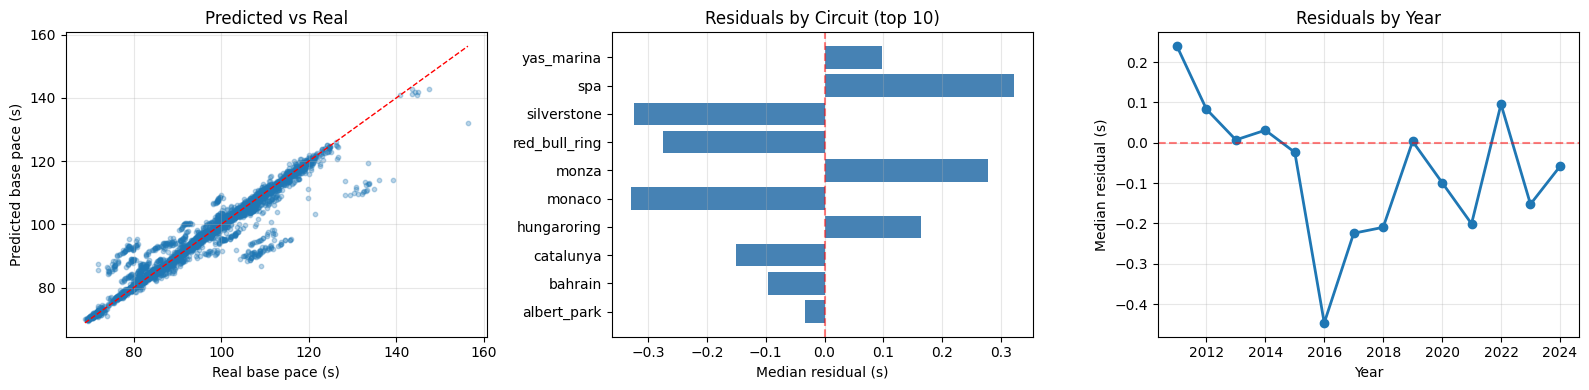

In [19]:
# Стартовая позиция = позиция на круге 1
start_pos = (
    df_clean[df_clean['lap'] == 1]
    .groupby(['raceId', 'driver_code'])['position']
    .first()
    .rename('start_position')
)

class BasePaceModel:

    XGB_PARAMS = dict(
        n_estimators=400, max_depth=5, learning_rate=0.04,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=10, random_state=42
    )

    FEATURES = [
        'circuit_id', 'constructor_id', 'driver_id',
        'weather_id', 'temperature', 'humidity',
        'wind_speed', 'precipitation', 'year',
        'start_position',
    ]

    def __init__(self):
        self.model  = XGBRegressor(**self.XGB_PARAMS)
        self.fitted = False
        self.circuit_avg_pace_ = {}

    @staticmethod
    def compute_targets(df_clean):
        base = (
            df_clean[
                df_clean['tyre_life'].between(3, 6) &
                (df_clean['stint'] == 1)
            ]
            .groupby(['raceId', 'driver_code'])
            .agg(
                base_pace      = ('time_lap',        'median'),
                circuit_id     = ('circuit_id',      'first'),
                constructor_id = ('constructor_id',  'first'),
                driver_id      = ('driver_id',       'first'),
                weather_id     = ('weather_id',      'first'),
                temperature    = ('temperature',     'first'),
                humidity       = ('humidity',        'first'),
                wind_speed     = ('wind_speed',      'first'),
                precipitation  = ('precipitation',   'first'),
                year           = ('year',            'first'),
                circuitRef     = ('circuitRef',      'first'),
            )
            .reset_index()
        )
        # Добавляем стартовую позицию
        base = base.join(start_pos, on=['raceId', 'driver_code'])
        return base

    def fit(self, df_clean):
        d = self.compute_targets(df_clean)
        d = d[d['base_pace'].between(60, 200)]

        self.circuit_avg_pace_ = (
            d.groupby('circuitRef')['base_pace'].median().to_dict()
        )
        self.global_avg_pace_ = float(d['base_pace'].median())

        X = d[self.FEATURES].fillna(0)
        y = d['base_pace']

        gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        tr_idx, val_idx = next(gss.split(X, y, groups=d['raceId']))
        Xtr, Xv = X.iloc[tr_idx], X.iloc[val_idx]
        ytr, yv  = y.iloc[tr_idx], y.iloc[val_idx]

        self.model.fit(Xtr, ytr, eval_set=[(Xv, yv)], verbose=False)
        pred = self.model.predict(Xv)

        mae = mean_absolute_error(yv, pred)
        r2  = r2_score(yv, pred)
        self.fitted = True
        print(f"[BasePace Model] MAE={mae:.3f}s  R2={r2:.3f}  "
              f"n_train={len(Xtr):,}  n_val={len(Xv):,}")

        importances = pd.Series(
            self.model.feature_importances_, index=self.FEATURES
        ).sort_values(ascending=False)
        print(f"[BasePace Model] Top features: "
              f"{importances.index[0]}={importances.iloc[0]:.3f}  "
              f"{importances.index[1]}={importances.iloc[1]:.3f}  "
              f"{importances.index[2]}={importances.iloc[2]:.3f}")

    def predict(self, circuit_id, constructor_id, driver_id,
                weather_id=0, temperature=25., humidity=50.,
                wind_speed=10., precipitation=0., year=2024,
                circuitRef=None, start_position=10):
        if not self.fitted:
            return self.circuit_avg_pace_.get(circuitRef, self.global_avg_pace_)

        X = np.array([[circuit_id, constructor_id, driver_id,
                       weather_id, temperature, humidity,
                       wind_speed, precipitation, year,
                       start_position]])
        pred = float(self.model.predict(X)[0])

        fallback = self.circuit_avg_pace_.get(circuitRef, self.global_avg_pace_)
        if pred < 55 or pred > 220:
            return fallback
        return pred

    def plot_predictions(self, df_clean):
        d = self.compute_targets(df_clean)
        d = d[d['base_pace'].between(60, 200)]
        X = d[self.FEATURES].fillna(0)
        d['predicted'] = self.model.predict(X)
        d['residual']  = d['base_pace'] - d['predicted']

        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        axes[0].scatter(d['base_pace'], d['predicted'], alpha=0.3, s=10)
        lims = [d['base_pace'].min(), d['base_pace'].max()]
        axes[0].plot(lims, lims, 'r--', linewidth=1)
        axes[0].set_xlabel('Real base pace (s)')
        axes[0].set_ylabel('Predicted base pace (s)')
        axes[0].set_title('Predicted vs Real')
        axes[0].grid(alpha=0.3)

        top_circuits = d['circuitRef'].value_counts().head(10).index
        res_by_circuit = d[d['circuitRef'].isin(top_circuits)].groupby('circuitRef')['residual'].median()
        axes[1].barh(res_by_circuit.index, res_by_circuit.values, color='steelblue')
        axes[1].axvline(0, color='red', linestyle='--', alpha=0.5)
        axes[1].set_xlabel('Median residual (s)')
        axes[1].set_title('Residuals by Circuit (top 10)')
        axes[1].grid(axis='x', alpha=0.3)

        res_by_year = d.groupby('year')['residual'].median()
        axes[2].plot(res_by_year.index, res_by_year.values, marker='o', linewidth=2)
        axes[2].axhline(0, color='red', linestyle='--', alpha=0.5)
        axes[2].set_xlabel('Year')
        axes[2].set_ylabel('Median residual (s)')
        axes[2].set_title('Residuals by Year')
        axes[2].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()


base_pace_model = BasePaceModel()
base_pace_model.fit(df_clean)
base_pace_model.plot_predictions(df_clean)

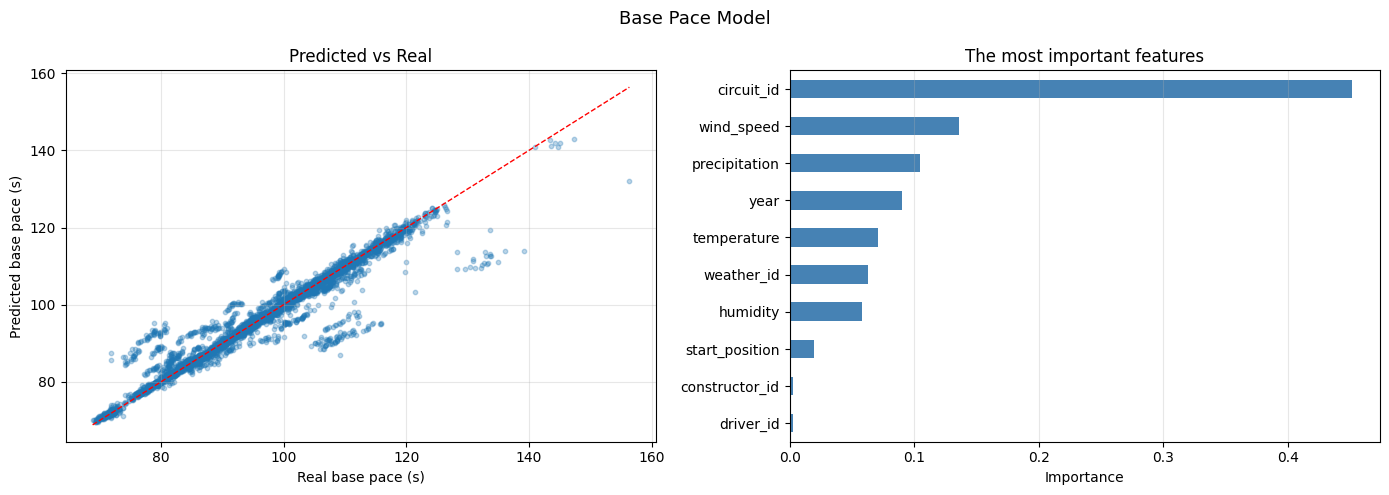

In [20]:
# просто графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Real
d = base_pace_model.compute_targets(df_clean)
d = d[d['base_pace'].between(60, 200)]
X = d[base_pace_model.FEATURES].fillna(0)
d['predicted'] = base_pace_model.model.predict(X)

ax = axes[0]
ax.scatter(d['base_pace'], d['predicted'], alpha=0.3, s=10)
lims = [d['base_pace'].min(), d['base_pace'].max()]
ax.plot(lims, lims, 'r--', linewidth=1)
ax.set_xlabel('Real base pace (s)')
ax.set_ylabel('Predicted base pace (s)')
ax.set_title('Predicted vs Real')
ax.grid(alpha=0.3)

# Top Features
ax = axes[1]
importances = pd.Series(
    base_pace_model.model.feature_importances_,
    index=base_pace_model.FEATURES
).sort_values(ascending=True)
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('The most important features')
ax.set_xlabel('Importance')
ax.grid(axis='x', alpha=0.3)

plt.suptitle('Base Pace Model', fontsize=13)
plt.tight_layout()
plt.savefig('base_pace_model.png', dpi=150, bbox_inches='tight')
plt.show()

### Pit-stop duration model

Predicts pit-stop time from circuit (pit lane length), constructor,
weather and SC status. XGBoost with GroupShuffleSplit by raceId.
MAE = 1.7s, R² = 0.42. Circuit is the dominant feature (0.46) —
pit lane length ranges from 20.5s (Hockenheim) to 28s+ on slower
circuits. Residual std = 2.5s is used as noise in simulation.

In [21]:
class PitStopModel:

    FEATURES = ['circuit_id', 'constructor_id', 'weather_id', 'year', 'safety_car']

    def __init__(self):
        self.model = XGBRegressor(
            n_estimators=200, max_depth=4,
            learning_rate=0.05, subsample=0.8,
            random_state=42
        )
        self.circuit_avg_     = {}
        self.constructor_avg_ = {}
        self.global_avg_      = 23.5
        self.residual_std_    = 3.4
        self.fitted = False

    def fit(self, df):
        d = df[df['pit'] > 0].copy()
        d = d[d['time_pit'].between(15, 35)]

        # Fallback агрегаты
        self.circuit_avg_     = d.groupby('circuitRef')['time_pit'].median().to_dict()
        self.constructor_avg_ = d.groupby('constructor')['time_pit'].median().to_dict()
        self.global_avg_      = float(d['time_pit'].median())

        X = d[self.FEATURES].fillna(0)
        y = d['time_pit']

        # GroupShuffleSplit по raceId
        gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        tr_idx, val_idx = next(gss.split(X, y, groups=d['raceId']))
        Xtr, Xv = X.iloc[tr_idx], X.iloc[val_idx]
        ytr, yv  = y.iloc[tr_idx], y.iloc[val_idx]

        self.model.fit(Xtr, ytr, eval_set=[(Xv, yv)], verbose=False)
        pred = self.model.predict(Xv)

        mae = mean_absolute_error(yv, pred)
        r2  = r2_score(yv, pred)

        # Std остатков — для шума в симуляции
        self.residual_std_ = float(np.std(yv - pred))
        self.fitted = True

        print(f"[PitStop Model] MAE={mae:.3f}s  R2={r2:.3f}  "
              f"residual_std={self.residual_std_:.3f}s  n={len(Xtr):,}")

        importances = pd.Series(
            self.model.feature_importances_, index=self.FEATURES
        ).sort_values(ascending=False)
        print(f"[PitStop Model] Top features:")
        for feat, imp in importances.items():
            print(f"  {feat:20s} {imp:.3f}")

    def predict(self, circuit_id, constructor_id, weather_id=0,
                year=2024, safety_car=0, add_noise=True):
        if not self.fitted:
            return self.global_avg_

        X = np.array([[circuit_id, constructor_id, weather_id,
                       year, safety_car]])
        pred = float(self.model.predict(X)[0])
        pred = np.clip(pred, 15, 40)

        if add_noise:
            pred += np.random.normal(0, self.residual_std_)
            pred = np.clip(pred, 15, 40)

        return pred


pit_model = PitStopModel()
pit_model.fit(df)

[PitStop Model] MAE=1.703s  R2=0.419  residual_std=2.493s  n=8,455
[PitStop Model] Top features:
  circuit_id           0.459
  weather_id           0.251
  year                 0.124
  safety_car           0.123
  constructor_id       0.042


### Integrated simulation environment

The simulation environment combines all five models into a
step-by-step race simulator with a gym-compatible interface.
At each lap, the agent observes a 13-dimensional state vector
(lap fraction, tyre life, compound, SC status, weather,
laps remaining, Pirelli rule compliance) and selects one of
four actions: no pit, pit for SOFT, MEDIUM or HARD.

Lap time is computed as:
  lap_time = base_pace + tyre_degradation + track_evolution
           + SC_penalty + pit_time + noise(0, 0.9s)

Two hard constraints are enforced via action masking:
  - Pirelli rule: at least 2 different dry compounds per race
  - MAX_TYRE_LIFE: mandatory pit at historical 95th percentile
    stint length (SOFT=31, MEDIUM=38, HARD=47 laps)

F1SimEnvironment created
Observation dim: 13
Action dim:      4

Test:
  Laps:       52
  Race rime:  96.53 min

Pit-stops:
 lap compound  tyre_life  pit_time
   1     HARD          1 27.237945
   3   MEDIUM          1 31.128203
   5     SOFT          1 22.097509
   6     HARD          1 27.283851
   7   MEDIUM          1 32.262649
   8     HARD          1 28.548480
   9   MEDIUM          1 27.113269
  10     HARD          1 30.974481
  11   MEDIUM          1 28.037518
  12     SOFT          1 25.174844
  14     HARD          1 30.807276
  15     SOFT          1 24.662985
  17     HARD          1 23.934205
  18   MEDIUM          1 30.060410
  20     HARD          1 30.097604
  21   MEDIUM          1 28.330300
  22     SOFT          1 26.370602
  23   MEDIUM          1 28.420491
  24     SOFT          1 30.564120
  25   MEDIUM          1 30.658075
  27     SOFT          1 29.351347
  29   MEDIUM          1 27.545441
  31     SOFT          1 27.751796
  33   MEDIUM          1 27.692609
 

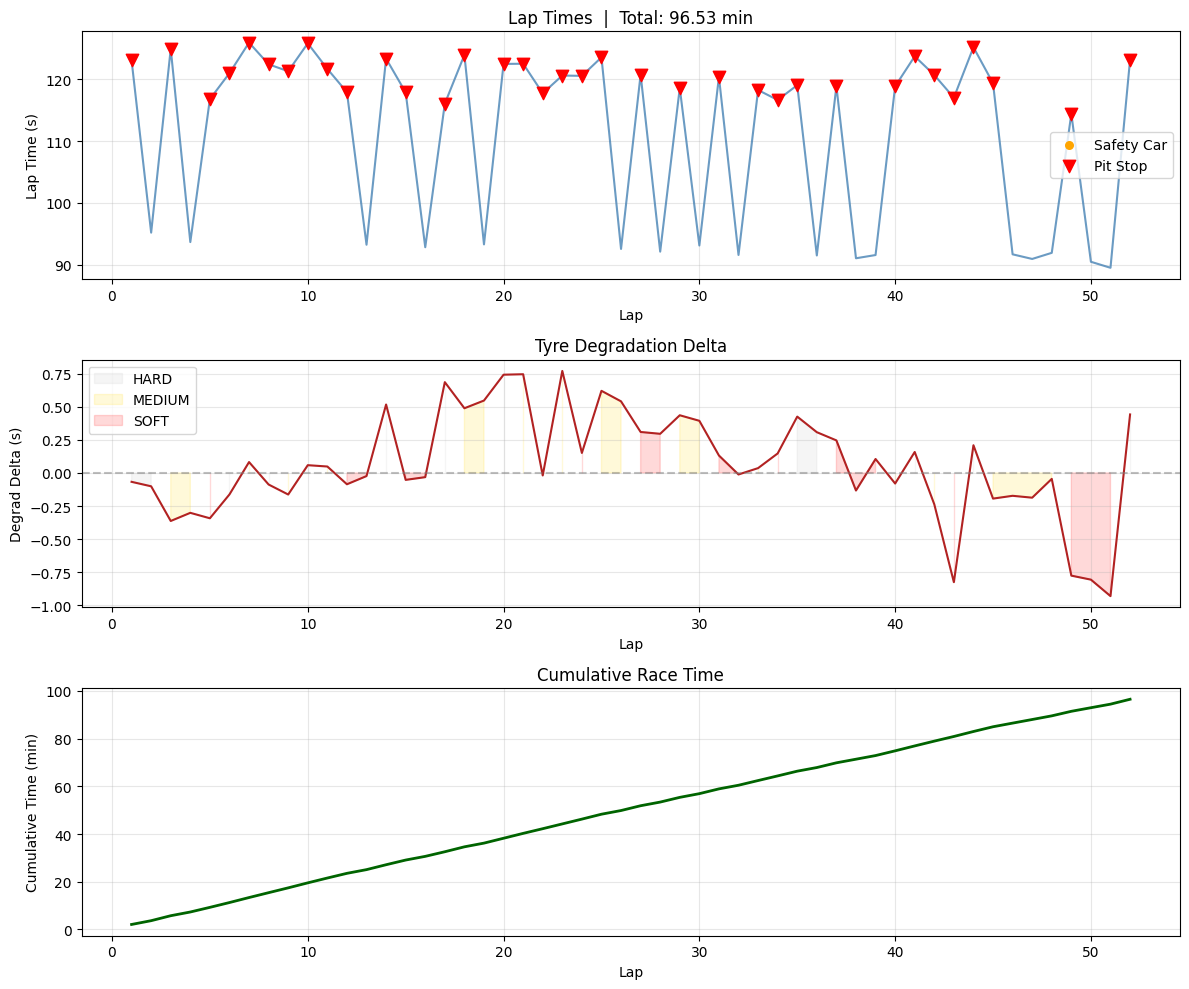

In [24]:
class F1SimEnvironment:

    COMPOUNDS      = {1: 'SOFT', 2: 'MEDIUM', 3: 'HARD'}
    COMPOUND_IDS   = {'SOFT': 1, 'MEDIUM': 2, 'HARD': 3}
    NOISE_STD      = 0.9

    SC_PENALTY_BY_LAP = {
        1: 33.8, 2: 39.8, 3: 41.7, 4: 40.2, 5: 38.1,
        6: 37.7, 7: 35.6, 8: 32.1, 9: 31.7, 10: 30.6,
    }
    SC_PENALTY_DEFAULT = 35.0

    MAX_TYRE_LIFE = {'SOFT': 31, 'MEDIUM': 38, 'HARD': 47,
                     'INTERMEDIATE': 38, 'WET': 20}

    OBS_DIM    = 13
    ACTION_DIM = 4

    def __init__(self, tyre_model, sc_model, pit_model, base_pace_model, df_ref):
        self.tyre_model      = tyre_model
        self.sc_model        = sc_model
        self.pit_model       = pit_model
        self.base_pace_model = base_pace_model
        self.df_ref          = df_ref

    def _get_race_params(self, circuitRef, year):
        sub = self.df_ref[
            (self.df_ref['circuitRef'] == circuitRef) &
            (self.df_ref['year'] == year)
        ]
        if len(sub) == 0:
            sub = self.df_ref[self.df_ref['circuitRef'] == circuitRef]
        if len(sub) == 0:
            return {'circuit_id': 0, 'total_laps': 55}
        return {
            'circuit_id': int(sub['circuit_id'].iloc[0]),
            'total_laps': int(sub['lap'].max()),
        }

    def _get_obs(self, state):
        return np.array([
            state['lap'] / state['total_laps'],
            state['tyre_life'] / 50.0,
            state['compound_id'] / 3.0,
            float(state['sc_active']),
            state['weather_id'] / 1.0,
            state['temperature'] / 40.0,
            state['humidity'] / 100.0,
            state['wind_speed'] / 30.0,
            state['precipitation'] / 10.0,
            (state['total_laps'] - state['lap']) / state['total_laps'],
            float('SOFT'   in state['used_compounds']),
            float('MEDIUM' in state['used_compounds']),
            float('HARD'   in state['used_compounds']),
        ], dtype=np.float32)

    def get_valid_actions(self, state):
        valid    = [0, 1, 2, 3]
        used     = state['used_compounds']
        laps_rem = state['total_laps'] - state['lap']
        current  = state['current_compound']

        # Нельзя менять на тот же compound
        current_action = self.COMPOUND_IDS.get(current, 0)
        valid = [a for a in valid if a != current_action]

        # Принудительный пит если превышен MAX_TYRE_LIFE
        max_life = self.MAX_TYRE_LIFE.get(current, 38)
        if state['tyre_life'] >= max_life:
            valid = [a for a in valid if a != 0]

        # Правило Pirelli
        if laps_rem <= 5 and len(used) < 2:
            valid = [a for a in valid if a != 0]

        # Safety net
        if not valid:
            valid = [a for a in [1, 2, 3] if a != current_action]

        return valid

    def _action_mask(self, state):
        mask = np.zeros(self.ACTION_DIM, dtype=bool)
        for a in self.get_valid_actions(state):
            mask[a] = True
        return mask

    def step(self, state, action):
        lap        = state['lap']
        total_laps = state['total_laps']
        lap_frac   = lap / total_laps

        # Обработка действия
        is_pit              = (action > 0)
        new_compound        = self.COMPOUNDS.get(action, state['current_compound'])
        pit_time            = 0.0
        tyre_age_before_pit = state['tyre_life']  # for reward shaping

        if is_pit:
            pit_time = self.pit_model.predict(
                circuit_id     = state['circuit_id'],
                constructor_id = state['constructor_id'],
                weather_id     = state['weather_id'],
                year           = state['year'],
                safety_car     = int(state['sc_active']),
                add_noise      = True
            )
            tyre_life      = 1
            compound       = new_compound
            compound_id    = self.COMPOUND_IDS[compound]
            used_compounds = state['used_compounds'] | {compound}
        else:
            tyre_life      = state['tyre_life'] + 1
            compound       = state['current_compound']
            compound_id    = state['compound_id']
            used_compounds = state['used_compounds']

        # Safety Car
        sc_active    = state['sc_active']
        sc_remaining = state['sc_remaining']
        sc_lap_num   = state['sc_lap_num']

        if sc_remaining > 0:
            sc_remaining -= 1
            sc_lap_num   += 1
            if sc_remaining == 0:
                sc_active  = False
                sc_lap_num = 0
        else:
            duration = self.sc_model.sample_sc_start(
                lap_frac      = lap_frac,
                weather_id    = state['weather_id'],
                circuit_id    = state['circuit_id'],
                temperature   = state['temperature'],
                precipitation = state['precipitation'],
                humidity      = state['humidity'],
                wind_speed    = state['wind_speed'],
                year          = state['year'],
                circuitRef    = state['circuitRef']
            )
            if duration > 0:
                sc_active    = True
                sc_remaining = duration - 1
                sc_lap_num   = 1
            else:
                sc_active  = False
                sc_lap_num = 0

        # Деградация шин
        fuel_effect  = (total_laps - lap) * 1.8 * 0.03
        degrad_delta = self.tyre_model.predict_delta(
            tyre_life     = tyre_life,
            compound      = compound,
            lap_frac      = lap_frac,
            weather_id    = state['weather_id'],
            circuit_id    = state['circuit_id'],
            temperature   = state['temperature'],
            humidity      = state['humidity'],
            wind_speed    = state['wind_speed'],
            precipitation = state['precipitation'],
            fuel_effect   = fuel_effect
        )

        # SC penalty
        sc_penalty = 0.0
        if sc_active:
            sc_penalty = self.SC_PENALTY_BY_LAP.get(sc_lap_num, self.SC_PENALTY_DEFAULT)

        # Резинизация трассы
        anchor_lap_frac     = 5 / total_laps
        rubbering           = self.tyre_model.rubbering_effect(lap_frac)
        rubbering_anchor    = self.tyre_model.rubbering_effect(anchor_lap_frac)
        rubbering_corrected = rubbering - rubbering_anchor

        # Время круга
        noise    = np.random.normal(0, self.NOISE_STD)
        lap_time = (state['base_pace'] + degrad_delta + rubbering_corrected
                    + sc_penalty + pit_time + noise)
        lap_time = max(state['base_pace'] * 0.95, lap_time)

        # Reward
        reward = -lap_time / state['base_pace']

        # Shaping 1: бонус/штраф за timing пит-стопа
        if is_pit:
            cap = self.MAX_TYRE_LIFE.get(state['current_compound'], 38)
            if tyre_age_before_pit >= cap * 0.6:
                reward += 0.3   # своевременный пит
            else:
                reward -= 0.5   # слишком ранний пит

        # Shaping 2: штраф за деградацию сверх нормы
        if degrad_delta > 0:
            reward -= degrad_delta / state['base_pace']

        # Next state
        next_lap   = lap + 1
        done       = (next_lap > total_laps)
        next_state = {
            **state,
            'lap':              next_lap,
            'tyre_life':        tyre_life,
            'current_compound': compound,
            'compound_id':      compound_id,
            'sc_active':        sc_active,
            'sc_remaining':     sc_remaining,
            'sc_lap_num':       sc_lap_num,
            'used_compounds':   used_compounds,
            'last_lap_time':    lap_time,
            'total_time':       state['total_time'] + lap_time,
        }

        obs  = self._get_obs(next_state)
        mask = self._action_mask(next_state)

        info = {
            'lap':          lap,
            'lap_time':     lap_time,
            'degrad_delta': degrad_delta,
            'sc_active':    sc_active,
            'sc_penalty':   sc_penalty,
            'pit_time':     pit_time,
            'compound':     compound,
            'tyre_life':    tyre_life,
            'total_time':   next_state['total_time'],
            'action_mask':  mask,
        }

        return next_state, obs, reward, done, info

    def reset(self, circuitRef, year, weather_type,
              temperature, precipitation, humidity, wind_speed,
              constructor_id, driver_id,
              start_compound='SOFT', seed=None):

        if seed is not None:
            np.random.seed(seed)

        race_params = self._get_race_params(circuitRef, year)
        circuit_id  = race_params['circuit_id']
        total_laps  = race_params['total_laps']
        weather_id  = 0 if weather_type == 'dry' else 1

        base_pace = self.base_pace_model.predict(
            circuit_id     = circuit_id,
            constructor_id = constructor_id,
            driver_id      = driver_id,
            weather_id     = weather_id,
            temperature    = temperature,
            humidity       = humidity,
            wind_speed     = wind_speed,
            precipitation  = precipitation,
            year           = year,
            circuitRef     = circuitRef
        )

        state = {
            'circuitRef':       circuitRef,
            'circuit_id':       circuit_id,
            'total_laps':       total_laps,
            'year':             year,
            'weather_id':       weather_id,
            'temperature':      temperature,
            'precipitation':    precipitation,
            'humidity':         humidity,
            'wind_speed':       wind_speed,
            'constructor_id':   constructor_id,
            'driver_id':        driver_id,
            'base_pace':        base_pace,
            'lap':              1,
            'tyre_life':        4,
            'current_compound': start_compound,
            'compound_id':      self.COMPOUND_IDS[start_compound],
            'used_compounds':   {start_compound},
            'sc_active':        False,
            'sc_remaining':     0,
            'sc_lap_num':       0,
            'total_time':       0.0,
            'last_lap_time':    0.0,
        }

        obs  = self._get_obs(state)
        mask = self._action_mask(state)
        return state, obs, mask

    def simulate_race(self, circuitRef, year, weather_type,
                      temperature, precipitation, humidity, wind_speed,
                      constructor_id, driver_id,
                      policy=None, start_compound='SOFT', seed=None):
        state, obs, mask = self.reset(
            circuitRef, year, weather_type,
            temperature, precipitation, humidity, wind_speed,
            constructor_id, driver_id, start_compound, seed
        )

        laps_data    = []
        total_reward = 0.0
        done         = False

        while not done:
            if policy is not None:
                action = policy(obs, mask, state)
            else:
                valid  = self.get_valid_actions(state)
                action = int(np.random.choice(valid))

            next_state, obs, reward, done, info = self.step(state, action)
            total_reward += reward
            laps_data.append(info)
            state = next_state

        laps_df = pd.DataFrame(laps_data)
        return {
            'total_time':   state['total_time'],
            'total_reward': total_reward,
            'total_laps':   state['total_laps'],
            'laps_df':      laps_df,
            'final_state':  state,
        }

    def run_monte_carlo(self, n=200, policy=None, **race_kwargs):
        results = []
        for i in range(n):
            r = self.simulate_race(seed=i, policy=policy, **race_kwargs)
            results.append({
                'sim':          i,
                'total_time':   r['total_time'],
                'total_reward': r['total_reward'],
            })
        return pd.DataFrame(results)

    def plot_race(self, result):
        laps_df = result['laps_df']
        fig, axes = plt.subplots(3, 1, figsize=(12, 10))

        ax = axes[0]
        ax.plot(laps_df['lap'], laps_df['lap_time'],
                color='steelblue', linewidth=1.5, alpha=0.8)
        sc_laps  = laps_df[laps_df['sc_active']]
        pit_laps = laps_df[laps_df['pit_time'] > 0]
        ax.scatter(sc_laps['lap'],  sc_laps['lap_time'],
                   color='orange', zorder=5, s=30, label='Safety Car')
        ax.scatter(pit_laps['lap'], pit_laps['lap_time'],
                   color='red', zorder=5, s=80, marker='v', label='Pit Stop')
        ax.set_xlabel('Lap'); ax.set_ylabel('Lap Time (s)')
        ax.set_title(f"Lap Times  |  Total: {result['total_time']/60:.2f} min")
        ax.legend(); ax.grid(alpha=0.3)

        ax = axes[1]
        ax.plot(laps_df['lap'], laps_df['degrad_delta'],
                color='firebrick', linewidth=1.5)
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        colors = {'SOFT': 'red', 'MEDIUM': 'gold', 'HARD': 'silver'}
        for comp in laps_df['compound'].unique():
            mask = laps_df['compound'] == comp
            ax.fill_between(laps_df['lap'], laps_df['degrad_delta'],
                            where=mask, alpha=0.15,
                            color=colors.get(comp, 'blue'), label=comp)
        ax.set_xlabel('Lap'); ax.set_ylabel('Degrad Delta (s)')
        ax.set_title('Tyre Degradation Delta')
        ax.legend(); ax.grid(alpha=0.3)

        ax = axes[2]
        ax.plot(laps_df['lap'], laps_df['lap_time'].cumsum() / 60,
                color='darkgreen', linewidth=2)
        ax.set_xlabel('Lap'); ax.set_ylabel('Cumulative Time (min)')
        ax.set_title('Cumulative Race Time')
        ax.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()


# Инициализация среды

sim_env = F1SimEnvironment(
    tyre_model      = tyre_model,
    sc_model        = sc_model,
    pit_model       = pit_model,
    base_pace_model = base_pace_model,
    df_ref          = df
)
print("F1SimEnvironment created")
print(f"Observation dim: {sim_env.OBS_DIM}")
print(f"Action dim:      {sim_env.ACTION_DIM}")



# Быстрый тест

result = sim_env.simulate_race(
    circuitRef     = 'silverstone',
    year           = 2024,
    weather_type   = 'dry',
    temperature    = 22.0,
    precipitation  = 0.0,
    humidity       = 60.0,
    wind_speed     = 15.0,
    constructor_id = int(df[df['constructor']=='Mercedes']['constructor_id'].iloc[0]),
    driver_id      = int(df[df['driver_code']=='HAM']['driver_id'].iloc[0]),
    start_compound = 'SOFT',
    seed           = 42
)

print(f"\nTest:")
print(f"  Laps:       {result['total_laps']}")
print(f"  Race rime:  {result['total_time']/60:.2f} min")
#print(f"  Total reward: {result['total_reward']:.3f}")
print(f"\nPit-stops:")
pit_laps = result['laps_df'][result['laps_df']['pit_time'] > 0]
print(pit_laps[['lap','compound','tyre_life','pit_time']].to_string(index=False))
print(f"\nSC periods: {result['laps_df']['sc_active'].sum()} laps")

sim_env.plot_race(result)

# Testing Hypotheses

### H1. Pit Timing Hypothesis
The relative timing of a pit stop within the race significantly affects post-pit position change.

In [8]:
from scipy import stats

df_pits = df.copy().sort_values(['raceId', 'driver_code', 'lap'])

df_pits['position_prev']   = df_pits.groupby(['raceId', 'driver_code'])['position'].shift(1)
df_pits['position_change'] = df_pits['position'] - df_pits['position_prev']
df_pits = df_pits[df_pits['pit'] > 0].copy()
df_pits['lap_frac'] = df_pits.groupby('raceId')['lap'].transform(lambda x: x / x.max())

def pit_phase(lap_frac):
    if lap_frac < 0.33:
        return 'early'
    elif lap_frac < 0.66:
        return 'mid'
    else:
        return 'late'

df_pits['phase'] = df_pits['lap_frac'].apply(pit_phase)

early = df_pits[df_pits['phase'] == 'early']['position_change'].dropna()
mid   = df_pits[df_pits['phase'] == 'mid']['position_change'].dropna()
late  = df_pits[df_pits['phase'] == 'late']['position_change'].dropna()

stat, p = stats.kruskal(early, mid, late)
print(f"Kruskal-Wallis: H={stat:.3f}, p={p:.6f}")
print(f"\nMean:")
print(f"  early: {early.mean():.3f}  n={len(early)}")
print(f"  mid:   {mid.mean():.3f}  n={len(mid)}")
print(f"  late:  {late.mean():.3f}  n={len(late)}")

stat_em, p_em = stats.mannwhitneyu(early, mid,  alternative='greater')
stat_el, p_el = stats.mannwhitneyu(early, late, alternative='greater')
stat_ml, p_ml = stats.mannwhitneyu(mid,   late, alternative='greater')
print(f"\nMann-Whitney (early > mid):  p={p_em:.6f}")
print(f"Mann-Whitney (early > late): p={p_el:.6f}")
print(f"Mann-Whitney (mid > late):   p={p_ml:.6f}")

Kruskal-Wallis: H=89.314, p=0.000000

Mean:
  early: 1.064  n=3325
  mid:   0.873  n=3979
  late:  0.555  n=3663

Mann-Whitney (early > mid):  p=0.160209
Mann-Whitney (early > late): p=0.000000
Mann-Whitney (mid > late):   p=0.000000


### H2. Safety Car Mitigation Hypothesis
Safety Car presence significantly reduces the positional cost of a pit stop.

In [10]:
sc_pits    = df_pits[df_pits['safety_car'] == 1]['position_change'].dropna()
green_pits = df_pits[df_pits['safety_car'] == 0]['position_change'].dropna()

print(f"Mean:")
print(f"  SC:    {sc_pits.mean():.3f}  n={len(sc_pits)}")
print(f"  green: {green_pits.mean():.3f}  n={len(green_pits)}")
print(f"Medians:")
print(f"  SC:    {sc_pits.median():.3f}")
print(f"  green: {green_pits.median():.3f}")

stat, p = stats.mannwhitneyu(sc_pits, green_pits, alternative='less')
print(f"Mann-Whitney (SC < green, SC лучше): p={p:.6f}")

Mean:
  SC:    0.222  n=1499
  green: 0.920  n=9468
Medians:
  SC:    0.000
  green: 0.000
Mann-Whitney (SC < green, SC лучше): p=0.000000


### H3. Tire Degradation Structure Hypothesis
Lap time degradation within a stint follows a nonlinear increasing pattern.

In [29]:
# Убираем первые 2 круга стинта - аномалия холодных шин
degrad_by_tyre_life = (
    df_clean[
        df_clean['target_degrad_clean'].notna() &
        df_clean['tyre_life'].between(3, 35)
    ]
    .groupby('tyre_life')['target_degrad_clean']
    .median()
)

x = degrad_by_tyre_life.index.values.astype(float)
y = degrad_by_tyre_life.values

coef_lin  = np.polyfit(x, y, 1)
y_lin     = np.polyval(coef_lin, x)
r2_lin    = r2_score(y, y_lin)

coef_poly = np.polyfit(x, y, 2)
y_poly    = np.polyval(coef_poly, x)
r2_poly   = r2_score(y, y_poly)

print(f"R² linear:       {r2_lin:.4f}")
print(f"R² polynomial: {r2_poly:.4f}")
print(f"Coefficient x²:    {coef_poly[0]:.6f}")

# Тест на нелинейность — сравниваем приросты деградации
deltas = np.diff(y)
print(f"\nAverage Degradation Increase:")
print(f"  laps 3-15:  {deltas[:12].mean():.4f}s/lap")
print(f"  laps 15-35: {deltas[12:].mean():.4f}s/lap")

R² linear:       0.7821
R² polynomial: 0.9818
Coefficient x²:    -0.002008

Average Degradation Increase:
  laps 3-15:  0.0808s/lap
  laps 15-35: 0.0141s/lap


In [29]:
from scipy import stats
from sklearn.linear_model import LinearRegression

x = degrad_by_tyre_life.index.values.reshape(-1, 1)
y = degrad_by_tyre_life.values

# Линейная модель
X_lin  = x
X_poly = np.hstack([x, x**2])

# F-test: улучшает ли добавление x² модель значимо?
from sklearn.linear_model import LinearRegression
from scipy.stats import f

lin  = LinearRegression().fit(X_lin,  y)
poly = LinearRegression().fit(X_poly, y)

ss_res_lin  = np.sum((y - lin.predict(X_lin))**2)
ss_res_poly = np.sum((y - poly.predict(X_poly))**2)

n  = len(y)
p1 = 2  # параметров в линейной
p2 = 3  # параметров в полиномиальной

F = ((ss_res_lin - ss_res_poly) / (p2 - p1)) / (ss_res_poly / (n - p2))
p_value = 1 - f.cdf(F, p2 - p1, n - p2)

print(f"F-statistic: {F:.3f}")
print(f"p-value:     {p_value:.6f}")

F-statistic: 330.036
p-value:     0.000000


### H4. Team Operational Effect Hypothesis
Team-level operational efficiency significantly influences pit stop outcomes.

In [30]:
# Считаем медианное время пит-стопа и среднее изменение позиции по командам
team_stats = (
    df_pits[df_pits['time_pit'] > 0]
    .groupby('constructor')
    .agg(
        median_pit_time    = ('time_pit',        'median'),
        mean_pos_change    = ('position_change',  'mean'),
        n                  = ('time_pit',         'count')
    )
    .reset_index()
    .dropna()
)

print(team_stats.sort_values('median_pit_time').to_string(index=False))

# Корреляция Спирмена — непараметрическая
stat, p = stats.spearmanr(team_stats['median_pit_time'],
                           team_stats['mean_pos_change'])
print(f"\nSpearman correlation: r={stat:.3f}, p={p:.6f}")

   constructor  median_pit_time  mean_pos_change    n
      Mercedes          22.9270         0.655827 1134
         Lotus          23.0010         1.425000   41
      Lotus F1          23.0270         0.948640  336
    Toro Rosso          23.1630         1.318966  243
      Caterham          23.1670         0.875000  321
  Aston Martin          23.2130         0.744770 1235
      Red Bull          23.2340         0.822092 1060
      Williams          23.3205         1.011841  968
       Renault          23.3485         0.823529   88
    RB F1 Team          23.5630         0.857364  671
       McLaren          23.5635         0.764045  646
       Ferrari          23.7320         0.784965  592
    Alfa Romeo          23.9355         0.885714  506
  Haas F1 Team          23.9930         0.931540 1287
      Marussia          24.0640         0.445378  243
Alpine F1 Team          24.1510         0.917184  504
        Sauber          24.2810         0.741036 1051
    AlphaTauri          24.3

### H5. Circuit Strategy Hypothesis
The optimal number of pit stops varies significantly across circuits.


In [30]:
# Берём число питов на гонщика за гонку
pits_per_driver = (
    df[df['pit'] > 0]
    .groupby(['raceId', 'circuitRef', 'driver_code'])['pit']
    .count()
    .reset_index()
    .rename(columns={'pit': 'n_pits'})
)

pits_by_circuit = (
    pits_per_driver
    .groupby('circuitRef')['n_pits']
    .median()
    .sort_values()
)

def get_pit_count(circuitRef):
    median_pits = pits_by_circuit.get(circuitRef, 2.0)
    if median_pits <= 1.5:
        return 1
    elif median_pits <= 2.5:
        return 2
    else:
        return 3

pits_per_driver['category'] = pits_per_driver['circuitRef'].apply(get_pit_count)

# Kruskal-Wallis между трассами
groups = [group['n_pits'].values
          for _, group in pits_per_driver.groupby('circuitRef')]

stat, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis: H={stat:.3f}, p={p:.6f}")
print(f"Number of Circuits: {len(groups)}")

# Медианы по категориям
print(f"\nMedians by caterogy:")
for cat in [1, 2, 3]:
    vals = pits_per_driver[pits_per_driver['category'] == cat]['n_pits']
    print(f"  {cat}-stop: median={vals.median():.2f}  mean={vals.mean():.2f}  n={len(vals)}")

# Kruskal-Wallis между категориями
g1 = pits_per_driver[pits_per_driver['category'] == 1]['n_pits']
g2 = pits_per_driver[pits_per_driver['category'] == 2]['n_pits']
g3 = pits_per_driver[pits_per_driver['category'] == 3]['n_pits']

stat2, p2 = stats.kruskal(g1, g2, g3)
print(f"\nKruskal-Wallis between categories: H={stat2:.3f}, p={p2:.6f}")

stat12, p12 = stats.mannwhitneyu(g1, g2, alternative='less')
stat23, p23 = stats.mannwhitneyu(g2, g3, alternative='less')
print(f"Mann-Whitney (1-stop < 2-stop): p={p12:.6f}")
print(f"Mann-Whitney (2-stop < 3-stop): p={p23:.6f}")

Kruskal-Wallis: H=1156.913, p=0.000000
Number of Circuits: 35

Medians by caterogy:
  1-stop: median=1.00  mean=1.47  n=1128
  2-stop: median=2.00  mean=2.10  n=3879
  3-stop: median=3.00  mean=2.78  n=568

Kruskal-Wallis between categories: H=775.466, p=0.000000
Mann-Whitney (1-stop < 2-stop): p=0.000000
Mann-Whitney (2-stop < 3-stop): p=0.000000


# Strategies

## Baseline

Rule-based baseline policy pits when tyre_life reaches the
60th percentile of historical stint lengths for the given
circuit and compound. Compound sequence follows a fixed
progression: SOFT -> MEDIUM -> HARD. For Silverstone, this
produces a typical 2-stop strategy (laps ~15 and ~38),
achieving a median race time of 81.35 min over 300 Monte
Carlo simulations (std = 0.63 min).

interlagos SOFT: порог = 20 кругов
interlagos MEDIUM: порог = 19 кругов
interlagos HARD: порог = 25 кругов

Baseline результат:
  Время: 97.41 мин
  Пит-стопов: 3
 lap compound  tyre_life  pit_time
  17   MEDIUM          1 24.474658
  36     HARD          1 19.444325
  61   MEDIUM          1 23.302932


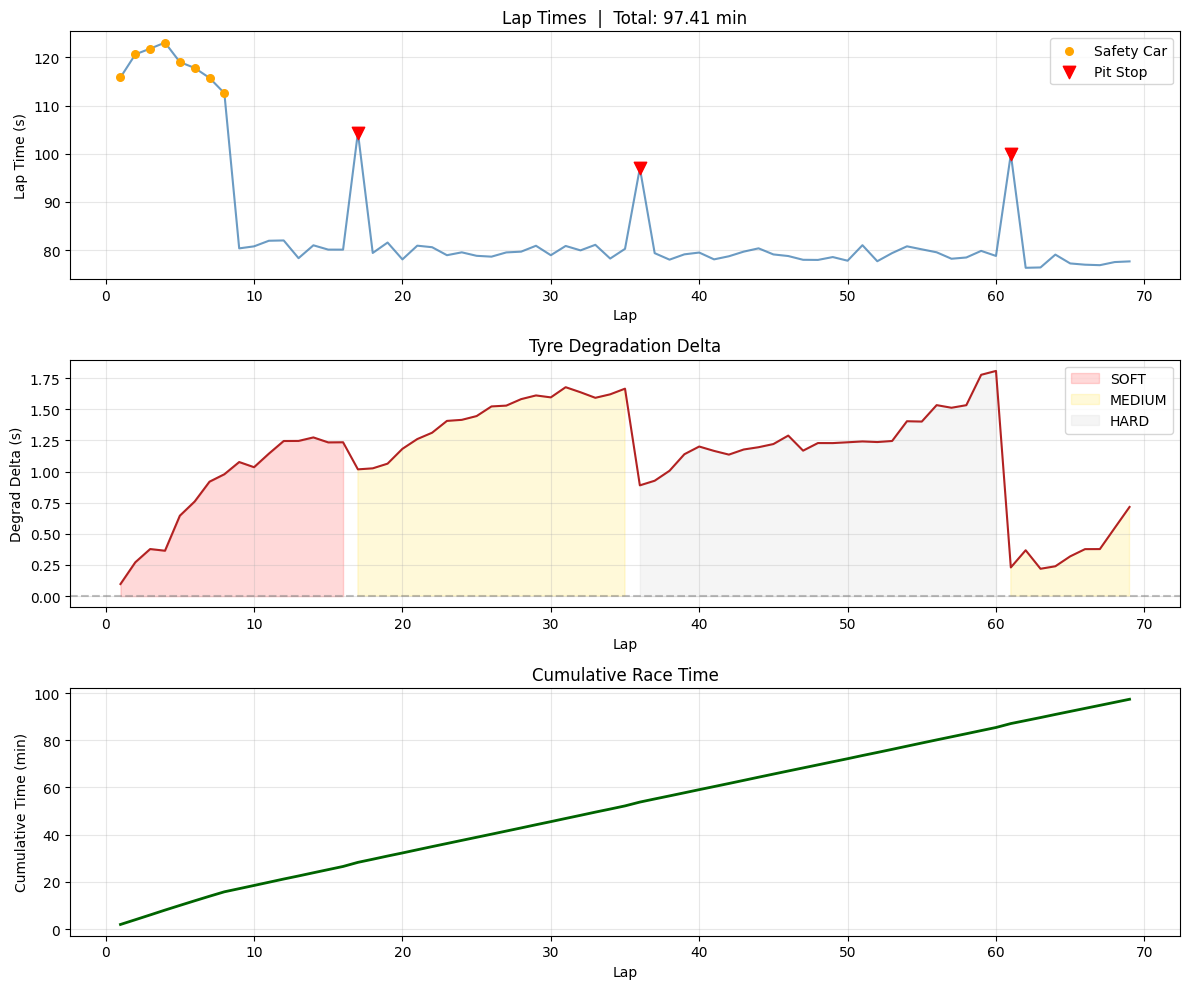

In [55]:
class RuleBasedPolicy:

    # Глобальные пороги
    GLOBAL_THRESHOLDS = {
        'SOFT':         15,
        'MEDIUM':       20,
        'HARD':         30,
        'INTERMEDIATE': 20,
        'WET':          10,
    }

    # Схема смены compound: что берём после текущего
    NEXT_COMPOUND = {
        'SOFT':   2,   # -> MEDIUM
        'MEDIUM': 3,   # -> HARD
        'HARD':   2,   # -> MEDIUM (если второй стинт на HARD)
    }

    def __init__(self, df, quantile=0.6):
        self.quantile   = quantile
        self.thresholds = self._compute_thresholds(df)

    def _compute_thresholds(self, df):
        stint_lengths = (
            df[df['tyre_compound'].notna() & (df['tyre_compound'] != 'nan')]
            .groupby(['circuitRef', 'tyre_compound', 'raceId', 'driver_code'])['tyre_life']
            .max()
            .reset_index()
            .rename(columns={'tyre_life': 'stint_length'})
        )
        thresholds = (
            stint_lengths
            .groupby(['circuitRef', 'tyre_compound'])['stint_length']
            .quantile(self.quantile)
            .to_dict()
        )
        return thresholds

    def get_threshold(self, circuitRef, compound):
        key = (circuitRef, compound)
        if key in self.thresholds:
            return int(self.thresholds[key])
        return self.GLOBAL_THRESHOLDS.get(compound, 20)

    def __call__(self, obs, mask, state):
        tyre_life  = state['tyre_life']
        compound   = state['current_compound']
        circuitRef = state['circuitRef']
        laps_rem   = state['total_laps'] - state['lap']
        threshold  = self.get_threshold(circuitRef, compound)

        next_action = self.NEXT_COMPOUND.get(compound, 2)

        should_pit = tyre_life >= threshold

        if should_pit and mask[next_action]:
            return next_action

        if mask[0]:
            return 0

        # Если no-pit заблокирован правилом Pirelli — берём любой валидный пит
        for action in [2, 3, 1]:   # MEDIUM -> HARD -> SOFT
            if mask[action]:
                return action

        return 0


baseline_policy = RuleBasedPolicy(df, quantile=0.3)

for comp in ['SOFT', 'MEDIUM', 'HARD']:
    t = baseline_policy.get_threshold('interlagos', comp)
    print(f"interlagos {comp}: порог = {t} кругов")

# Тест
result_baseline = sim_env.simulate_race(
    circuitRef     = 'interlagos',
    year           = 2024,
    weather_type   = 'dry',
    temperature    = 22.0,
    precipitation  = 0.0,
    humidity       = 60.0,
    wind_speed     = 15.0,
    constructor_id = int(df[df['constructor']=='Mercedes']['constructor_id'].iloc[0]),
    driver_id      = int(df[df['driver_code']=='HAM']['driver_id'].iloc[0]),
    start_compound = 'SOFT',
    seed           = 42,
    policy         = baseline_policy
)



print(f"\nBaseline result:")
print(f"  Time: {result_baseline['total_time']/60:.2f} min")
pit_laps = result_baseline['laps_df'][result_baseline['laps_df']['pit_time'] > 0]
print(f"  Pit-stops: {len(pit_laps)}")
print(pit_laps[['lap','compound','tyre_life','pit_time']].to_string(index=False))

sim_env.plot_race(result_baseline)

In [58]:
#задать параметры и посчитать медиану
CONSTRUCTOR_ID = int(df[df['constructor'] == 'Mercedes']['constructor_id'].iloc[0])
DRIVER_ID      = int(df[df['driver_code'] == 'HAM']['driver_id'].iloc[0])

RACE_KWARGS = dict(
    circuitRef     = 'interlagos',
    year           = 2024,
    weather_type   = 'dry',
    temperature    = 22.0,
    precipitation  = 0.0,
    humidity       = 60.0,
    wind_speed     = 15.0,
    constructor_id = CONSTRUCTOR_ID,
    driver_id      = DRIVER_ID,
    start_compound = 'SOFT',
)

df_mc_baseline = sim_env.run_monte_carlo(n=300, policy=baseline_policy, **RACE_KWARGS)
BASELINE_MEDIAN = df_mc_baseline['total_time'].median() / 60
print(f"Baseline median: {BASELINE_MEDIAN:.3f} мин")

Baseline median: 95.866 мин


## Grid search

Exhaustive search over all reasonable 1-stop and 2-stop
strategies: pit lap × compound combinations, evaluated via
Monte Carlo simulation (50 runs per strategy, ~400 strategies
total). Identifies the optimal fixed strategy for a given
circuit and conditions.

Results for Silverstone 2024 (dry, Mercedes):
  Optimal: SOFT -> MEDIUM (lap 28) -> HARD
  Median:  81.03 min  (+19.2s vs baseline)

Key finding: the first pit lap has negligible impact on race
time (strategies with pit1 at laps 12, 15, 18, 21 yield
identical medians), while the second pit timing is more
critical — MEDIUM stints beyond lap 31 show measurable
degradation.

In [22]:
# Категории трасс по числу пит-стопов

# Считаем медианное число питов по трассе из данных
pits_per_driver = (
    df[df['pit'] > 0]
    .groupby(['raceId', 'circuitRef', 'driver_code'])['pit']
    .count()
    .reset_index()
    .rename(columns={'pit': 'n_pits'})
)

pits_by_circuit = (
    pits_per_driver
    .groupby('circuitRef')['n_pits']
    .median()
    .sort_values()
)

def get_pit_count(circuitRef):
    median_pits = pits_by_circuit.get(circuitRef, 2.0)
    if median_pits <= 1.5:
        return 1
    elif median_pits <= 2.5:
        return 2
    else:
        return 3

# Разбиваем трассы по категориям
categories = {1: [], 2: [], 3: []}
for circuit, median in pits_by_circuit.items():
    categories[get_pit_count(circuit)].append((circuit, median))

print("Track categories by number of pit stops (based on historical data)")
for n, circuits in categories.items():
    print(f"\n{n}-stop ({len(circuits)} races):")
    for c, m in circuits:
        print(f"  {c:25s} ")

print(f"\nTotal number {sum(len(v) for v in categories.values())}")

Track categories by number of pit stops (based on historical data)

1-stop (8 races):
  monaco                    
  miami                     
  jeddah                    
  imola                     
  sochi                     
  rodriguez                 
  ricard                    
  monza                     

2-stop (22 races):
  marina_bay                
  hungaroring               
  catalunya                 
  buddh                     
  albert_park               
  americas                  
  bahrain                   
  baku                      
  suzuka                    
  valencia                  
  silverstone               
  istanbul                  
  red_bull_ring             
  portimao                  
  shanghai                  
  nurburgring               
  vegas                     
  villeneuve                
  spa                       
  yas_marina                
  yeongam                   
  zandvoort                 

3-stop (5 races):
  los


GRID SEARCH: INTERLAGOS
Категория:   3-stop
Кругов:      69
Стратегий:   219

Прогон...
  0/219 готово...
  20/219 готово...
  40/219 готово...
  60/219 готово...
  80/219 готово...
  100/219 готово...
  120/219 готово...
  140/219 готово...
  160/219 готово...
  180/219 готово...
  200/219 готово...

Топ-10 стратегий:
                                                  strategy    median      mean      std
[('SOFT', 10), ('MEDIUM', 18), ('SOFT', 46), ('HARD', 69)] 95.918844 96.161469 2.084748
[('SOFT', 10), ('MEDIUM', 22), ('SOFT', 46), ('HARD', 69)] 95.918844 96.161469 2.084748
[('SOFT', 10), ('MEDIUM', 30), ('SOFT', 46), ('HARD', 69)] 95.918844 96.161469 2.084748
[('SOFT', 10), ('MEDIUM', 26), ('SOFT', 46), ('HARD', 69)] 95.918844 96.161469 2.084748
[('SOFT', 18), ('MEDIUM', 30), ('SOFT', 50), ('HARD', 69)] 95.926928 96.031853 2.062663
[('SOFT', 18), ('MEDIUM', 26), ('SOFT', 50), ('HARD', 69)] 95.926928 96.031853 2.062663
[('SOFT', 18), ('MEDIUM', 26), ('SOFT', 46), ('HARD', 69)] 95.

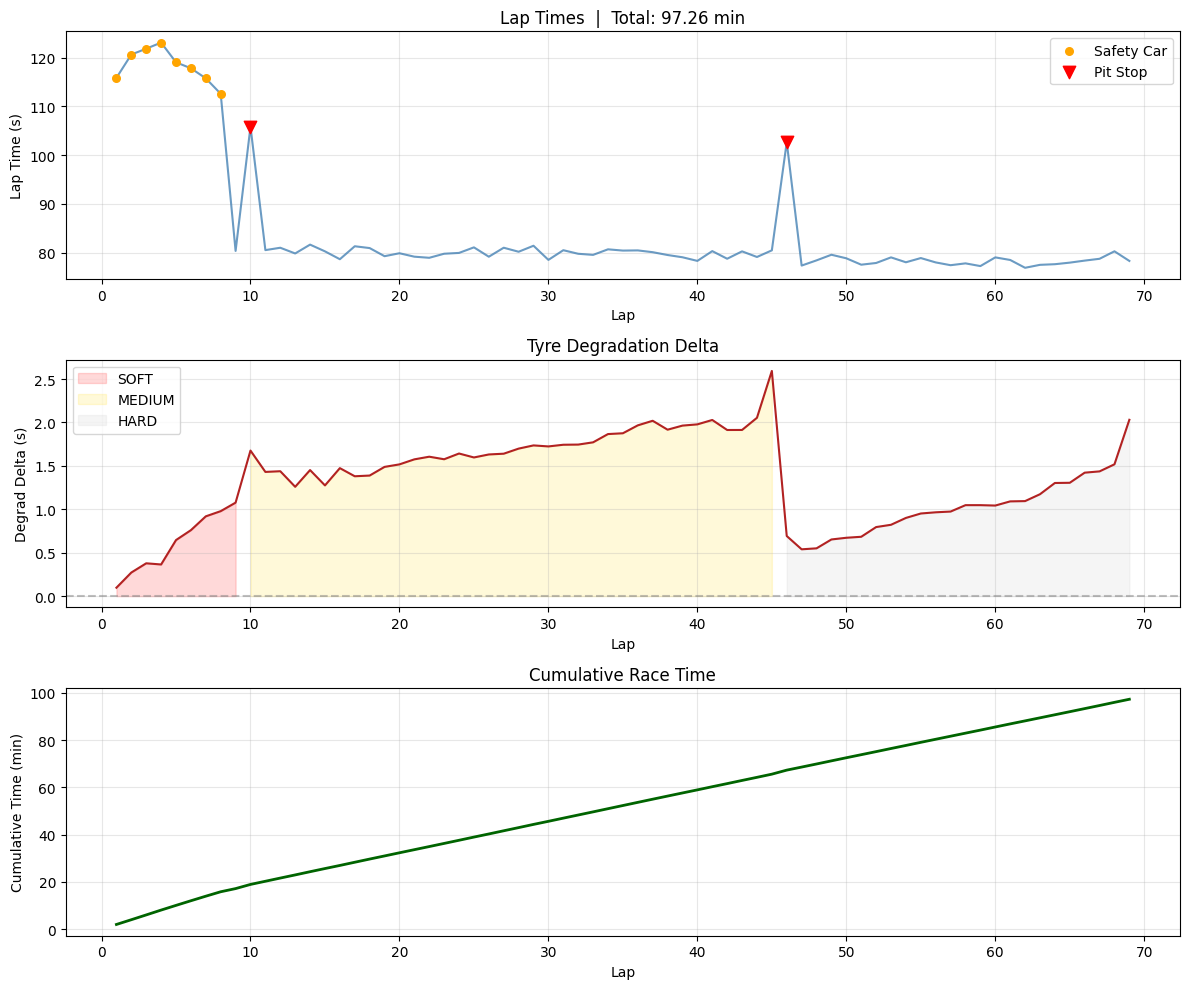

In [33]:
# Grid search: interlagos, 3 pit-stops

circuit    = RACE_KWARGS['circuitRef']
n_pits     = get_pit_count(circuit)
total_laps = sim_env._get_race_params(circuit, RACE_KWARGS['year'])['total_laps']

print(f"Grid search: {circuit.upper()}")
print(f"Category:   {n_pits}-stop")
print(f"Laps:      {total_laps}")

# Генерируем стратегии согласно категории
strategies = []

if n_pits == 1:
    for pit_lap in range(10, total_laps - 5, 3):
        for comp2 in ['MEDIUM', 'HARD']:
            strategies.append([('SOFT', pit_lap), (comp2, total_laps)])

elif n_pits == 2:
    for pit1 in range(10, 25, 3):
        for pit2 in range(pit1 + 10, total_laps - 8, 3):
            for comp2, comp3 in [('MEDIUM', 'HARD'), ('HARD', 'MEDIUM')]:
                strategies.append([
                    ('SOFT', pit1), (comp2, pit2), (comp3, total_laps)
                ])

elif n_pits == 3:
    for pit1 in range(10, 20, 4):
        for pit2 in range(pit1 + 8, 32, 4):
            for pit3 in range(pit2 + 8, total_laps - 5, 4):
                for c2, c3, c4 in [('MEDIUM', 'HARD',   'SOFT'),
                                    ('HARD',   'MEDIUM', 'SOFT'),
                                    ('MEDIUM', 'SOFT',   'HARD')]:
                    strategies.append([
                        ('SOFT', pit1), (c2, pit2),
                        (c3, pit3),     (c4, total_laps)
                    ])

print(f"Strategies:   {len(strategies)}")
print(f"\nRun...")

# Оцениваем каждую стратегию
results = []
for i, strat in enumerate(strategies):
    times = []
    for seed in range(50):
        def strat_policy(obs, mask, state, s=strat):
            for idx, (compound, end_lap) in enumerate(s):
                if state['lap'] <= end_lap:
                    if state['lap'] == end_lap and idx < len(s) - 1:
                        next_compound = s[idx + 1][0]
                        action = sim_env.COMPOUND_IDS.get(next_compound, 0)
                        if mask[action]:
                            return action
                    return 0
            return 0

        r = sim_env.simulate_race(seed=seed, policy=strat_policy, **RACE_KWARGS)
        times.append(r['total_time'])

    results.append({
        'strategy': str(strat),
        'median':   np.median(times) / 60,
        'mean':     np.mean(times)   / 60,
        'std':      np.std(times)    / 60,
    })

    if i % 20 == 0:
        print(f"  {i}/{len(strategies)} ready...")

df_results = pd.DataFrame(results).sort_values('median').reset_index(drop=True)

print(f"\nTop-10 strategies:")
print(df_results.head(10).to_string(index=False))
print(f"\nBaseline:        {BASELINE_MEDIAN:.3f} min")
print(f"Grid search optimisation: {df_results['median'].min():.3f} min")
print(f"Improvement:       {(BASELINE_MEDIAN - df_results['median'].min())*60:.1f} sec")

# Пример лучшей гонки
best_strat = eval(df_results.iloc[0]['strategy'])
print(f"The best strategy: {best_strat}")

def best_policy(obs, mask, state, s=best_strat):
    for idx, (compound, end_lap) in enumerate(s):
        if state['lap'] <= end_lap:
            if state['lap'] == end_lap and idx < len(s) - 1:
                next_compound = s[idx + 1][0]
                action = sim_env.COMPOUND_IDS.get(next_compound, 0)
                if mask[action]:
                    return action
            return 0
    return 0

result_best = sim_env.simulate_race(seed=42, policy=best_policy, **RACE_KWARGS)
print(f"Example of race: {result_best['total_time']/60:.2f} min")
pit_laps = result_best['laps_df'][result_best['laps_df']['pit_time'] > 0]
print(pit_laps[['lap','compound','tyre_life','pit_time']].to_string(index=False))
sim_env.plot_race(result_best)


GRID SEARCH: SILVERSTONE
Категория:   2-stop
Кругов:      52
Стратегий:   510

Прогон...
  0/510 готово...
  20/510 готово...
  40/510 готово...
  60/510 готово...
  80/510 готово...
  100/510 готово...
  120/510 готово...
  140/510 готово...
  160/510 готово...
  180/510 готово...
  200/510 готово...
  220/510 готово...
  240/510 готово...
  260/510 готово...
  280/510 готово...
  300/510 готово...
  320/510 готово...
  340/510 готово...
  360/510 готово...
  380/510 готово...
  400/510 готово...
  420/510 готово...
  440/510 готово...
  460/510 готово...
  480/510 готово...
  500/510 готово...

Топ-10 стратегий:
                                    strategy    median      mean      std
[('SOFT', 21), ('HARD', 35), ('MEDIUM', 52)] 81.666768 81.973805 0.940097
[('SOFT', 19), ('HARD', 35), ('MEDIUM', 52)] 81.673026 81.988204 0.936880
[('SOFT', 21), ('HARD', 36), ('MEDIUM', 52)] 81.677031 81.973010 0.943043
[('SOFT', 19), ('MEDIUM', 35), ('HARD', 52)] 81.684847 81.999983 0.936773
[('SOFT

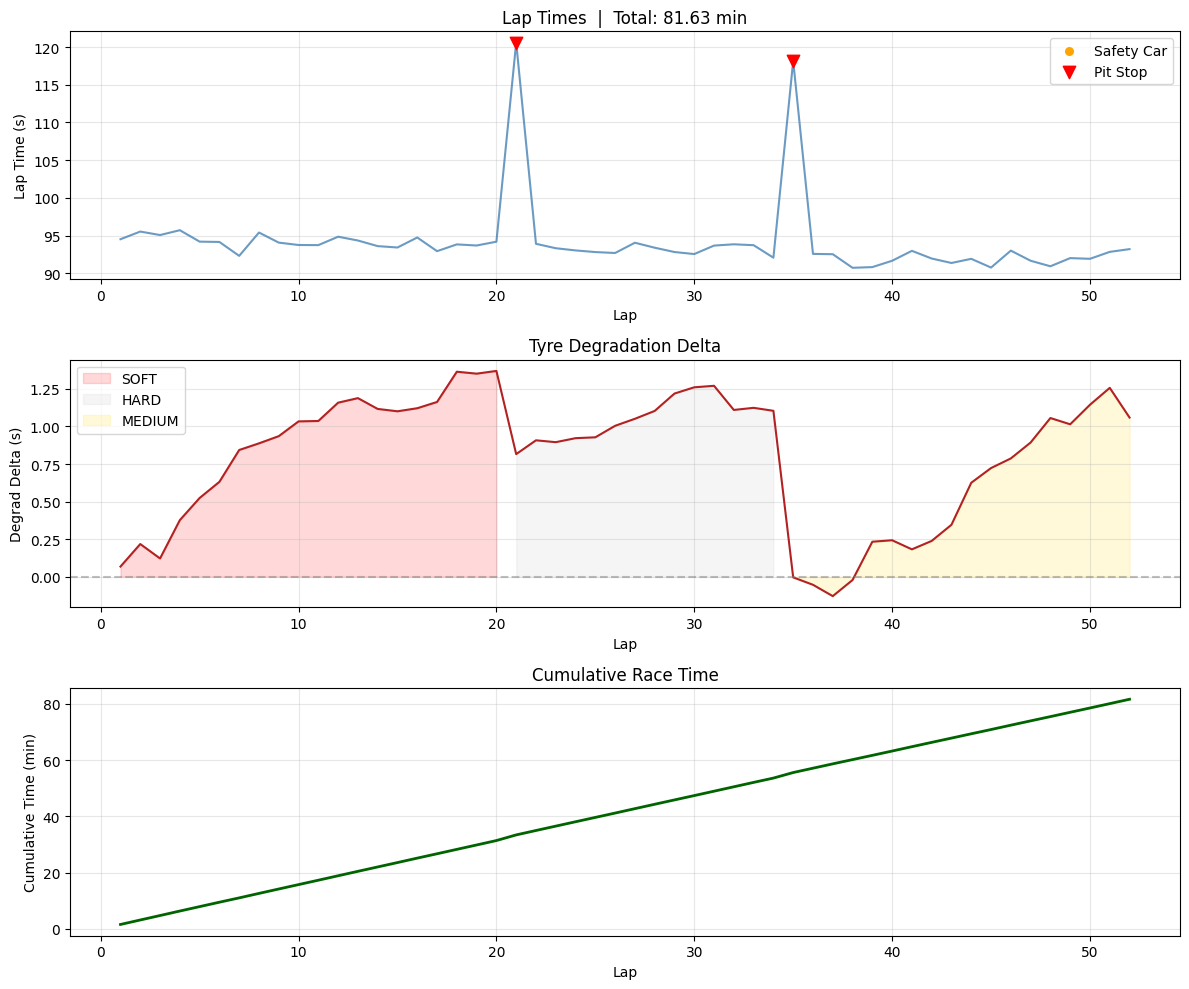

In [41]:
# Grid Search: Silverstone, 2 pit-stops
circuit    = RACE_KWARGS['circuitRef']
n_pits     = get_pit_count(circuit)
total_laps = sim_env._get_race_params(circuit, RACE_KWARGS['year'])['total_laps']

print(f"Grid search: {circuit.upper()}")
print(f"Category:   {n_pits}-stop")
print(f"Laps:      {total_laps}")

# Генерируем стратегии согласно категории
strategies = []

if n_pits == 1:
    for pit_lap in range(10, total_laps - 5, 1):
        for comp2 in ['MEDIUM', 'HARD']:
            strategies.append([('SOFT', pit_lap), (comp2, total_laps)])

elif n_pits == 2:
    for pit1 in range(10, 25, 1):
        for pit2 in range(pit1 + 10, total_laps - 8, 1):
            for comp2, comp3 in [('MEDIUM', 'HARD'), ('HARD', 'MEDIUM')]:
                strategies.append([
                    ('SOFT', pit1), (comp2, pit2), (comp3, total_laps)
                ])

elif n_pits == 3:
    for pit1 in range(10, 20, 1):
        for pit2 in range(pit1 + 8, 32, 3):
            for pit3 in range(pit2 + 8, total_laps - 5, 3):
                for c2, c3, c4 in [('MEDIUM', 'HARD',   'SOFT'),
                                    ('HARD',   'MEDIUM', 'SOFT'),
                                    ('MEDIUM', 'SOFT',   'HARD')]:
                    strategies.append([
                        ('SOFT', pit1), (c2, pit2),
                        (c3, pit3),     (c4, total_laps)
                    ])

print(f"Strategies:   {len(strategies)}")
print(f"\nRun...")

# Оцениваем каждую стратегию
results = []
for i, strat in enumerate(strategies):
    times = []
    for seed in range(50):
        def strat_policy(obs, mask, state, s=strat):
            for idx, (compound, end_lap) in enumerate(s):
                if state['lap'] <= end_lap:
                    if state['lap'] == end_lap and idx < len(s) - 1:
                        next_compound = s[idx + 1][0]
                        action = sim_env.COMPOUND_IDS.get(next_compound, 0)
                        if mask[action]:
                            return action
                    return 0
            return 0

        r = sim_env.simulate_race(seed=seed, policy=strat_policy, **RACE_KWARGS)
        times.append(r['total_time'])

    results.append({
        'strategy': str(strat),
        'median':   np.median(times) / 60,
        'mean':     np.mean(times)   / 60,
        'std':      np.std(times)    / 60,
    })

    if i % 20 == 0:
        print(f"  {i}/{len(strategies)} ready...")

df_results = pd.DataFrame(results).sort_values('median').reset_index(drop=True)

print(f"\nTop-10 strategies:")
print(df_results.head(10).to_string(index=False))
print(f"\nBaseline:        {BASELINE_MEDIAN:.3f} мин")
print(f"Grid search optimisation: {df_results['median'].min():.3f} мин")
print(f"Improvement:       {(BASELINE_MEDIAN - df_results['median'].min())*60:.1f} секунд")

# Пример лучшей гонки
best_strat = eval(df_results.iloc[0]['strategy'])
print(f"The best strategy: {best_strat}")

def best_policy(obs, mask, state, s=best_strat):
    for idx, (compound, end_lap) in enumerate(s):
        if state['lap'] <= end_lap:
            if state['lap'] == end_lap and idx < len(s) - 1:
                next_compound = s[idx + 1][0]
                action = sim_env.COMPOUND_IDS.get(next_compound, 0)
                if mask[action]:
                    return action
            return 0
    return 0

result_best = sim_env.simulate_race(seed=42, policy=best_policy, **RACE_KWARGS)
print(f"Example of race: {result_best['total_time']/60:.2f} min")
pit_laps = result_best['laps_df'][result_best['laps_df']['pit_time'] > 0]
print(pit_laps[['lap','compound','tyre_life','pit_time']].to_string(index=False))
sim_env.plot_race(result_best)

## Lookahead Policy

At each lap, the policy compares the expected cost of continuing
on current tyres versus pitting now, using analytical lookahead
over a 20-lap horizon (no simulations required).

expected_cost_no_pit  = Σ degradation(tyre_life + i, compound)
                        for i in range(min(laps_remaining, 20))
                      + cost of inevitable future pit stop

expected_cost_with_pit = effective_pit_time
                       + Σ degradation(i, new_compound)
                         for i in range(min(laps_remaining, 20))

Under Safety Car: effective_pit_time = −10s, reflecting that
a pit stop during SC costs approximately 23s but saves ~35s
in SC penalties that would otherwise be incurred while racing.
The policy does not pit under SC if fewer than 15 laps remain,
as fresh tyres would not recover the pit stop cost.

Constraints enforced:
  - No pit if tyre_life < 15 (< 5 under SC)
  - Pirelli rule: forced pit if < 15 laps remain and only
    one compound used
  - Compound selection: argmin expected degradation over horizon

In [36]:
def simulate_with_forced_sc(seed, strategy_policy, race_kwargs,
                             sc_lap=None, sc_duration=5):
    state, obs, mask = sim_env.reset(**race_kwargs, seed=seed)
    laps_data    = []
    total_reward = 0.0
    done         = False
    forced_sc    = False

    while not done:
        if sc_lap is not None and state['lap'] == sc_lap and not forced_sc:
            state['sc_active']    = True
            state['sc_remaining'] = sc_duration - 1
            state['sc_lap_num']   = 1
            forced_sc = True

        action = strategy_policy(obs, mask, state)
        next_state, obs, reward, done, info = sim_env.step(state, action)
        total_reward += reward
        laps_data.append(info)
        state = next_state

    return {
        'total_time':   state['total_time'],
        'total_reward': total_reward,
        'laps_df':      pd.DataFrame(laps_data),
        'final_state':  state,
    }

Test race
Time: 97.63 min
Pit-stops: 4
 lap compound  tyre_life  pit_time
   2     HARD          1 19.612458
   7     HARD          1 20.119049
  29   MEDIUM          1 23.680154
  45     HARD          1 25.709690


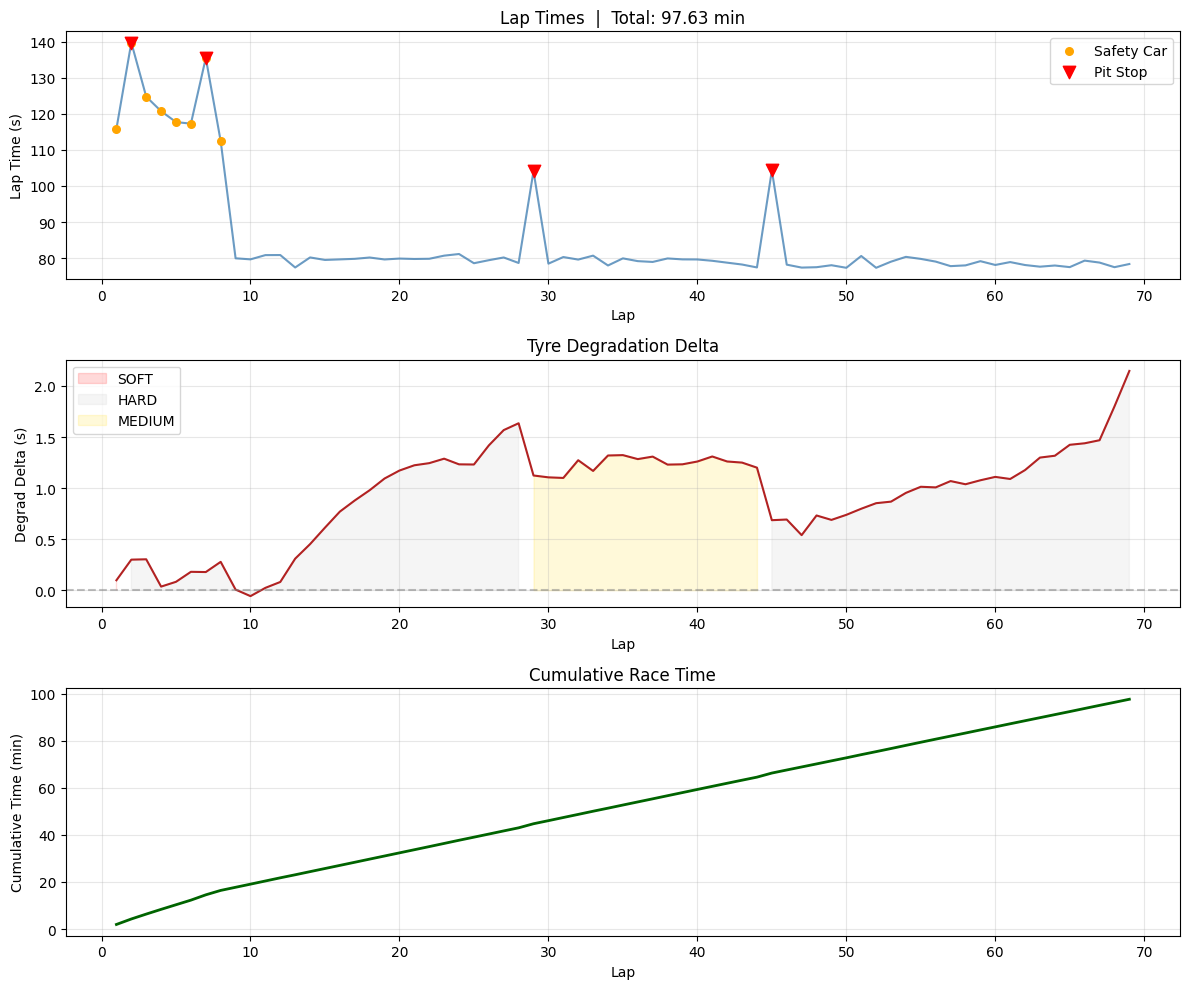


Monte Carlo 100 simulations

  Baseline median:     95.895 мин
  Grid search opt:     95.919 мин
  Lookahead median:    95.694 мин
  vs Baseline:         -12.0s

Lookahead vs Baseline — SC scenarios (50 simulations):
Scenario            Baseline    Lookahead      Delta
-------------------------------------------------------
no_sc                 96.347       95.944     -24.2s
sc_early              97.824       97.895 +      4.2s
sc_mid                98.104       97.898     -12.4s
sc_late               98.153       97.957     -11.7s
-------------------------------------------------------


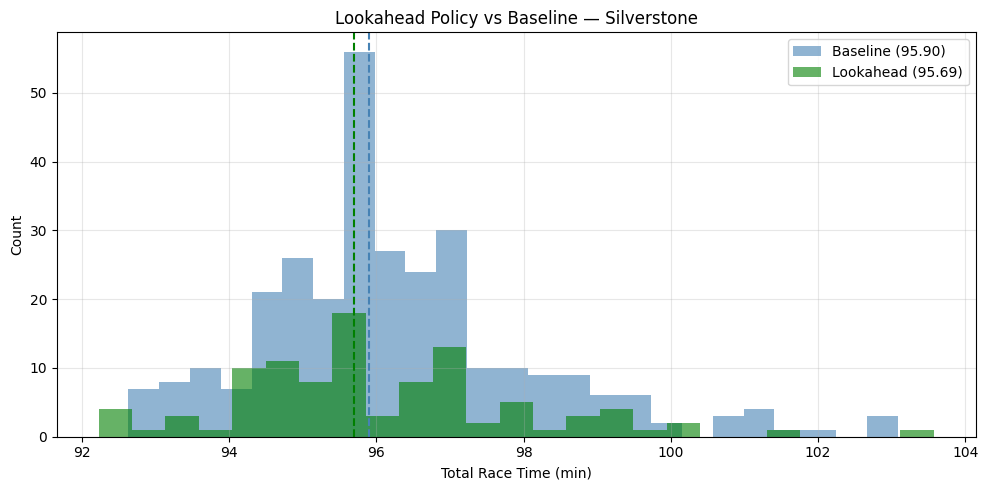

In [37]:
class LookaheadPolicy:

    PIT_TIME_BASE = 23.5
    MAX_HORIZON   = 20

    def __init__(self, tyre_model, pit_model):
        self.tyre_model = tyre_model
        self.pit_model  = pit_model

    def _expected_degrad(self, tyre_life_start, compound, laps,
                          lap_frac, weather_id, circuit_id,
                          temperature, humidity, wind_speed,
                          precipitation, total_laps, current_lap):
        # Суммарная положительная деградация на следующих N кругах
        total = 0.
        for i in range(laps):
            tl       = tyre_life_start + i
            lf       = min((current_lap + i) / total_laps, 1.0)
            fuel_eff = max(0, (total_laps - current_lap - i) * 1.8 * 0.03)
            delta    = self.tyre_model.predict_delta(
                tyre_life     = tl,
                compound      = compound,
                lap_frac      = lf,
                weather_id    = weather_id,
                circuit_id    = circuit_id,
                temperature   = temperature,
                humidity      = humidity,
                wind_speed    = wind_speed,
                precipitation = precipitation,
                fuel_effect   = fuel_eff
            )
            total += max(0, delta)
        return total

    def __call__(self, obs, mask, state):
        valid_actions = [i for i, v in enumerate(mask) if v]

        if len(valid_actions) == 1:
            return valid_actions[0]

        laps_rem = state['total_laps'] - state['lap']

        # Не заезжать на свежих шинах (под SC порог снижается до 5)
        min_tyre_life = 5 if state['sc_active'] else 15
        if state['tyre_life'] < min_tyre_life and 0 in valid_actions:
            return 0

        # Не заезжать под SC если осталось мало кругов
        if state['sc_active'] and laps_rem < 15 and 0 in valid_actions:
          return 0

        # Правило Pirelli: если осталось <= 15 кругов и правило не выполнено
        if len(state['used_compounds']) < 2 and laps_rem <= 15:
            if 0 in valid_actions and len(valid_actions) > 1:
                valid_actions = [a for a in valid_actions if a != 0]

        # Если no-pit недоступен, выбираем лучший compound
        if 0 not in valid_actions:
            return self._best_compound(valid_actions, state)

        current_lap = state['lap']
        total_laps  = state['total_laps']
        horizon     = min(laps_rem, self.MAX_HORIZON)

        # Стоимость "ехать дальше"
        cost_no_pit = self._expected_degrad(
            tyre_life_start = state['tyre_life'],
            compound        = state['current_compound'],
            laps            = horizon,
            lap_frac        = current_lap / total_laps,
            weather_id      = state['weather_id'],
            circuit_id      = state['circuit_id'],
            temperature     = state['temperature'],
            humidity        = state['humidity'],
            wind_speed      = state['wind_speed'],
            precipitation   = state['precipitation'],
            total_laps      = total_laps,
            current_lap     = current_lap,
        )

        # Стоимость неизбежного будущего пита
        max_life    = sim_env.MAX_TYRE_LIFE.get(state['current_compound'], 38)
        laps_to_max = max_life - state['tyre_life']
        if laps_to_max <= laps_rem:
            cost_no_pit += self.PIT_TIME_BASE * (1.0 - laps_to_max / max_life)

        # Стоимость пит-стопа
        best_action, best_cost_pit = None, float('inf')

        for action in valid_actions:
            if action == 0:
                continue
            new_compound = {1: 'SOFT', 2: 'MEDIUM', 3: 'HARD'}.get(action)
            if new_compound is None:
                continue

            pit_time = self.pit_model.predict(
                circuit_id     = state['circuit_id'],
                constructor_id = state['constructor_id'],
                weather_id     = state['weather_id'],
                year           = state['year'],
                safety_car     = int(state['sc_active']),
                add_noise      = False
            )
            # пит-стоп под SC
            if state['sc_active']:
                pit_time = -10.0

            cost_pit = pit_time + self._expected_degrad(
                tyre_life_start = 1,
                compound        = new_compound,
                laps            = horizon,
                lap_frac        = current_lap / total_laps,
                weather_id      = state['weather_id'],
                circuit_id      = state['circuit_id'],
                temperature     = state['temperature'],
                humidity        = state['humidity'],
                wind_speed      = state['wind_speed'],
                precipitation   = state['precipitation'],
                total_laps      = total_laps,
                current_lap     = current_lap,
            )

            if cost_pit < best_cost_pit:
                best_cost_pit = cost_pit
                best_action   = action

        if best_cost_pit < cost_no_pit:
            return best_action
        return 0

    def _best_compound(self, valid_actions, state):
        """Выбирает compound с наименьшей суммарной деградацией."""
        best_action, best_cost = valid_actions[0], float('inf')
        for action in valid_actions:
            compound = {1: 'SOFT', 2: 'MEDIUM', 3: 'HARD'}.get(action)
            if compound is None:
                continue
            cost = self._expected_degrad(
                tyre_life_start = 1,
                compound        = compound,
                laps            = min(state['total_laps'] - state['lap'],
                                      self.MAX_HORIZON),
                lap_frac        = state['lap'] / state['total_laps'],
                weather_id      = state['weather_id'],
                circuit_id      = state['circuit_id'],
                temperature     = state['temperature'],
                humidity        = state['humidity'],
                wind_speed      = state['wind_speed'],
                precipitation   = state['precipitation'],
                total_laps      = state['total_laps'],
                current_lap     = state['lap'],
            )
            if cost < best_cost:
                best_cost   = cost
                best_action = action
        return best_action


# Инициализация и тест

lookahead_policy = LookaheadPolicy(
    tyre_model = tyre_model,
    pit_model  = pit_model,
)

# Тест — одна гонка
print("Test race")
result_la = sim_env.simulate_race(seed=42, policy=lookahead_policy, **RACE_KWARGS)
print(f"Time: {result_la['total_time']/60:.2f} min")
pit_laps = result_la['laps_df'][result_la['laps_df']['pit_time'] > 0]
print(f"Pit-stops: {len(pit_laps)}")
print(pit_laps[['lap','compound','tyre_life','pit_time']].to_string(index=False))
sim_env.plot_race(result_la)

# Monte Carlo
print("\nMonte Carlo 100 simulations")
df_mc_la = sim_env.run_monte_carlo(n=100, policy=lookahead_policy, **RACE_KWARGS)

print(f"\n{'='*45}")
print(f"  Baseline median:     {BASELINE_MEDIAN:.3f} мин")
print(f"  Grid search opt:     {df_results['median'].min():.3f} мин")
print(f"  Lookahead median:    {df_mc_la['total_time'].median()/60:.3f} мин")
delta = (df_mc_la['total_time'].median()/60 - BASELINE_MEDIAN) * 60
print(f"  vs Baseline:         {delta:+.1f}s")
print(f"{'='*45}")

# SC сценарии
print("\nLookahead vs Baseline — SC scenarios (50 simulations):")
print(f"{'Scenario':15s} {'Baseline':>12s} {'Lookahead':>12s} {'Delta':>10s}")
print("-" * 55)

sc_scenarios = {
    'no_sc':    None,
    'sc_early': 10,
    'sc_mid':   25,
    'sc_late':  40,
}

for scenario, sc_lap in sc_scenarios.items():
    times_b, times_la = [], []
    for seed in range(50):
        if sc_lap is None:
            rb = sim_env.simulate_race(seed=seed, policy=baseline_policy,  **RACE_KWARGS)
            rl = sim_env.simulate_race(seed=seed, policy=lookahead_policy, **RACE_KWARGS)
        else:
            rb = simulate_with_forced_sc(seed, baseline_policy,  RACE_KWARGS, sc_lap=sc_lap)
            rl = simulate_with_forced_sc(seed, lookahead_policy, RACE_KWARGS, sc_lap=sc_lap)
        times_b.append(rb['total_time'])
        times_la.append(rl['total_time'])

    med_b  = np.median(times_b)  / 60
    med_la = np.median(times_la) / 60
    delta  = (med_la - med_b) * 60
    sign   = '+' if delta > 0 else ''
    print(f"{scenario:15s} {med_b:>12.3f} {med_la:>12.3f} {sign}{delta:>9.1f}s")

print("-" * 55)

# Финальный график
fig, ax = plt.subplots(figsize=(10, 5))
for times, label, color in [
    (df_mc_baseline['total_time']/60,
     f'Baseline ({BASELINE_MEDIAN:.2f})', 'steelblue'),
    (df_mc_la['total_time']/60,
     f'Lookahead ({df_mc_la["total_time"].median()/60:.2f})', 'green'),
]:
    ax.hist(times, bins=25, alpha=0.6, label=label, color=color)
    ax.axvline(times.median(), color=color, linestyle='--', linewidth=1.5)

ax.set_xlabel('Total Race Time (min)')
ax.set_ylabel('Count')
ax.set_title('Lookahead Policy vs Baseline — Silverstone')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Strategy comparison

### Race with 2 pit-stops

In [25]:
'''
baseline strategy?
result_b = sim_env.simulate_race(seed=42, policy=baseline_policy, **RACE_KWARGS)
pit_laps = result_b['laps_df'][result_b['laps_df']['pit_time'] > 0]
print(pit_laps[['lap','compound','tyre_life']].to_string(index=False))
'''

 lap compound  tyre_life
  12   MEDIUM          1
  38     HARD          1


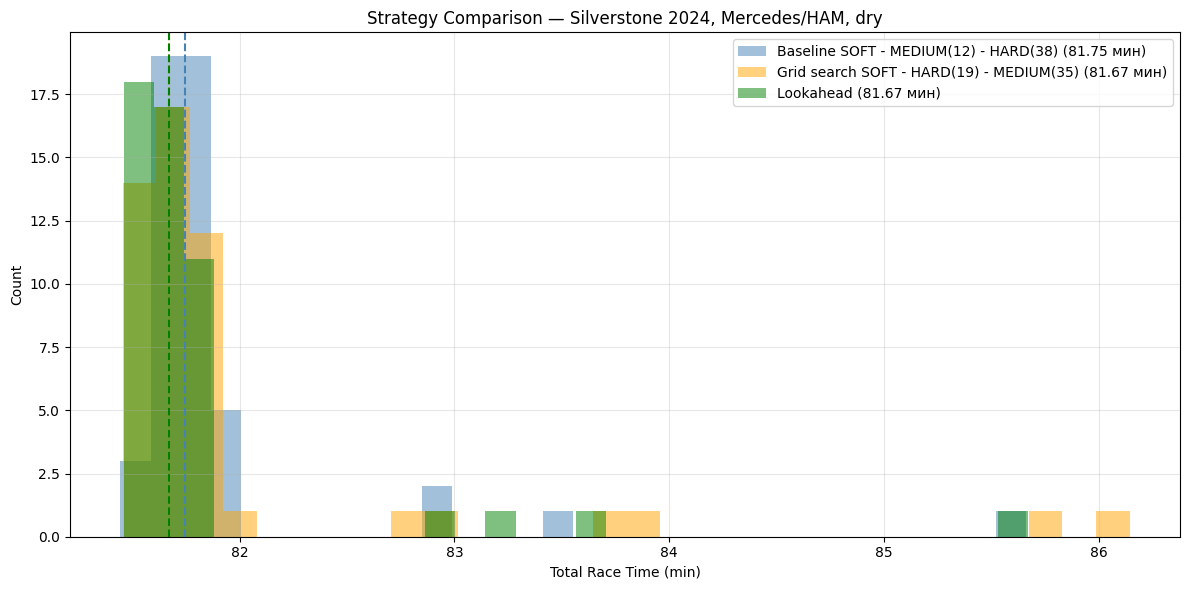

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
# Сравнение трех стратегий: сильверстоун, 2 пит-стопа
baseline_strat  = [('SOFT', 12), ('MEDIUM', 38), ('HARD', 52)]
gs_strat        = [('SOFT', 19), ('HARD', 35),   ('MEDIUM', 52)]

def make_policy(strat):
    def policy(obs, mask, state, s=strat):
        for idx, (compound, end_lap) in enumerate(s):
            if state['lap'] <= end_lap:
                if state['lap'] == end_lap and idx < len(s) - 1:
                    next_compound = s[idx + 1][0]
                    action = sim_env.COMPOUND_IDS.get(next_compound, 0)
                    if mask[action]:
                        return action
                return 0
        return 0
    return policy

policies_mc = {
    'Baseline SOFT - MEDIUM(12) - HARD(38)':    (make_policy(baseline_strat), 'steelblue'),
    'Grid search SOFT - HARD(19) - MEDIUM(35)': (make_policy(gs_strat),       'orange'),
    'Lookahead':                                 (lookahead_policy,            'green'),
}

fig, ax = plt.subplots(figsize=(12, 6))

for name, (policy, color) in policies_mc.items():
    times = []
    for seed in range(50):
        r = sim_env.simulate_race(seed=seed, policy=policy, **RACE_KWARGS)
        times.append(r['total_time'] / 60)
    median = np.median(times)
    ax.hist(times, bins=30, alpha=0.5, color=color,
            label=f'{name} ({median:.2f} мин)')
    ax.axvline(median, color=color, linestyle='--', linewidth=1.5)

ax.set_xlabel('Total Race Time (min)')
ax.set_ylabel('Count')
ax.set_title('Strategy Comparison — Silverstone 2024, Mercedes/HAM, dry')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('strategy_comparison.png')

### Race with 3 pit-stops

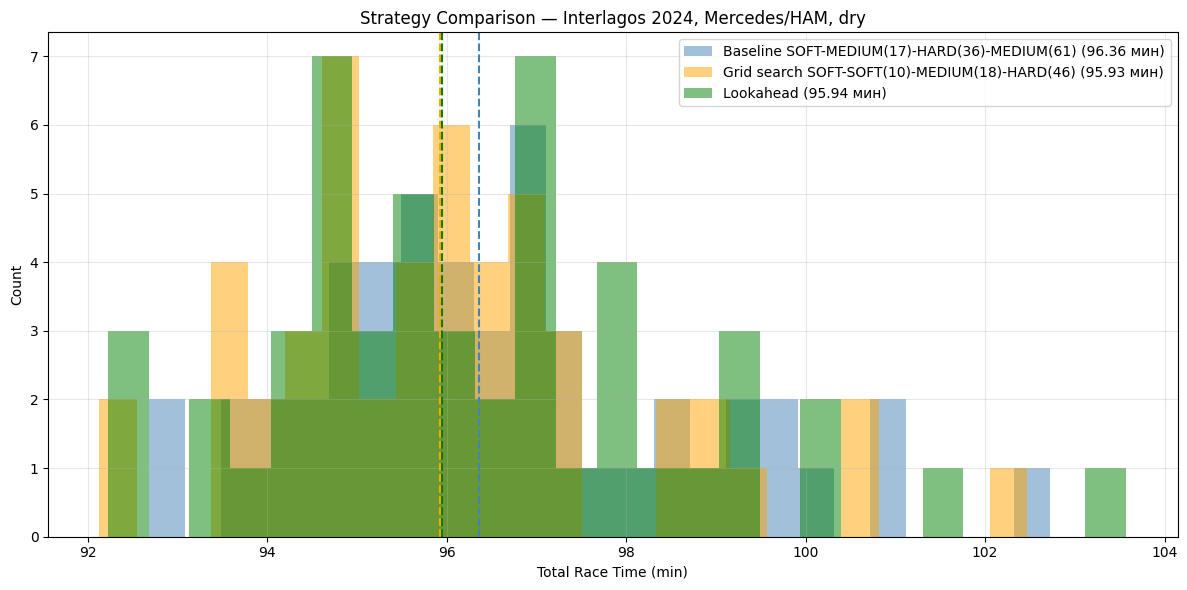

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [59]:
# Сравнение трех стратегий: интерлагос, 3 пит-стопа
baseline_strat  = [('SOFT', 17), ('MEDIUM', 36), ('HARD', 61), ('MEDIUM', 69)]
gs_strat        = [('SOFT', 10), ('SOFT', 18), ('MEDIUM', 46), ('HARD', 69)]

def make_policy(strat):
    def policy(obs, mask, state, s=strat):
        for idx, (compound, end_lap) in enumerate(s):
            if state['lap'] <= end_lap:
                if state['lap'] == end_lap and idx < len(s) - 1:
                    next_compound = s[idx + 1][0]
                    action = sim_env.COMPOUND_IDS.get(next_compound, 0)
                    if mask[action]:
                        return action
                return 0
        return 0
    return policy

policies_mc = {
    'Baseline SOFT-MEDIUM(17)-HARD(36)-MEDIUM(61)': (make_policy(baseline_strat), 'steelblue'),
    'Grid search SOFT-SOFT(10)-MEDIUM(18)-HARD(46)': (make_policy(gs_strat),      'orange'),
    'Lookahead':                                       (lookahead_policy,            'green'),
}

fig, ax = plt.subplots(figsize=(12, 6))

for name, (policy, color) in policies_mc.items():
    times = []
    for seed in range(50):
        r = sim_env.simulate_race(seed=seed, policy=policy, **RACE_KWARGS)
        times.append(r['total_time'] / 60)
    median = np.median(times)
    ax.hist(times, bins=25, alpha=0.5, color=color,
            label=f'{name} ({median:.2f} мин)')
    ax.axvline(median, color=color, linestyle='--', linewidth=1.5)

ax.set_xlabel('Total Race Time (min)')
ax.set_ylabel('Count')
ax.set_title('Strategy Comparison — Interlagos 2024, Mercedes/HAM, dry')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('strategy_comparison_interlagos.png', dpi=150, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('strategy_comparison_interlagos.png')

### Safety car scenario analysis

In [62]:
def simulate_with_forced_sc(seed, policy, race_kwargs, sc_lap=None, sc_duration=5):
    state, obs, mask = sim_env.reset(**race_kwargs, seed=seed)
    laps_data    = []
    total_reward = 0.0
    done         = False
    forced_sc    = False

    while not done:
        if sc_lap is not None and state['lap'] == sc_lap and not forced_sc:
            state['sc_active']    = True
            state['sc_remaining'] = sc_duration - 1
            state['sc_lap_num']   = 1
            forced_sc = True

        action = policy(obs, mask, state)
        next_state, obs, reward, done, info = sim_env.step(state, action)
        total_reward += reward
        laps_data.append(info)
        state = next_state

    return {
        'total_time':   state['total_time'],
        'total_reward': total_reward,
        'laps_df':      pd.DataFrame(laps_data),
        'final_state':  state,
    }

gs_strat_interlagos = [('SOFT', 10), ('MEDIUM', 18), ('SOFT', 46), ('HARD', 69)]

def gs_policy_interlagos(obs, mask, state, s=gs_strat_interlagos):
    for idx, (compound, end_lap) in enumerate(s):
        if state['lap'] <= end_lap:
            if state['lap'] == end_lap and idx < len(s) - 1:
                next_compound = s[idx + 1][0]
                action = sim_env.COMPOUND_IDS.get(next_compound, 0)
                if mask[action]:
                    return action
            return 0
    return 0

sc_scenarios = {
    'no_sc':    None,
    'sc_early': 10,
    'sc_mid':   30,
    'sc_late':  50,
}

policies = {
    'Baseline':    baseline_policy,
    'Grid search': gs_policy_interlagos,
    'Lookahead':   lookahead_policy,
}

print(f"{'Scenario':12s} {'Baseline':>10s} {'Grid search':>12s} {'Lookahead':>10s} {'GS vs B':>10s} {'LA vs B':>10s}")
print("-" * 65)

for scenario, sc_lap in sc_scenarios.items():
    row = {}
    for name, policy in policies.items():
        times = []
        for seed in range(50):
            if sc_lap is None:
                r = sim_env.simulate_race(seed=seed, policy=policy, **RACE_KWARGS)
            else:
                r = simulate_with_forced_sc(seed, policy, RACE_KWARGS, sc_lap=sc_lap)
            times.append(r['total_time'])
        row[name] = np.median(times) / 60

    delta_gs = (row['Grid search'] - row['Baseline']) * 60
    delta_la = (row['Lookahead']   - row['Baseline']) * 60
    sign_gs  = '+' if delta_gs > 0 else ''
    sign_la  = '+' if delta_la > 0 else ''
    print(f"{scenario:12s} {row['Baseline']:>10.3f} {row['Grid search']:>12.3f} "
          f"{row['Lookahead']:>10.3f} {sign_gs}{delta_gs:>9.1f}s {sign_la}{delta_la:>9.1f}s")

print("-" * 65)

Scenario       Baseline  Grid search  Lookahead    GS vs B    LA vs B
-----------------------------------------------------------------
no_sc            96.355       95.919     95.944     -26.2s     -24.6s
sc_early         98.046       97.614     97.895     -25.9s      -9.1s
sc_mid           98.131       98.060     97.976      -4.2s      -9.3s
sc_late          98.284       97.948     98.315     -20.1s +      1.9s
-----------------------------------------------------------------
